# Аналіз платіжних транзакцій

236 918 спроб оплати від 40 210 юзерів за січень-лютий 2026: якість даних, прохідність, chargeback-rate, виручка, LTV, календарний і когортний аналіз.

Ноутбук побудований як послідовність «питання, запит, результат, висновок». Уся агрегація зроблена в SQL (DuckDB) поверх одного очищеного шару, pandas і scipy використовуються для статистичних тестів і графіків.

1. Вхідні дані, аудит якості і препроцесинг
2. Частина 1. SQL: метрики на рівні юзера
3. Частина 2. Аналіз платежів: метрики, розрізи, значущість, структура відмов, LTV, календар, когорти
4. Аномалії та закономірності
5. Візуалізація висновків
6. Висновки та рекомендації

In [1]:
from pathlib import Path
import duckdb
import pandas as pd

In [2]:
DATA = Path('data/transactions.parquet')
DB = Path('payments.duckdb')
rebuild = False

if rebuild or not DB.exists():
    with duckdb.connect(DB) as build_con:
        build_con.execute(f"CREATE OR REPLACE TABLE transactions AS SELECT * FROM '{DATA}'")
        n_rows = build_con.sql('SELECT COUNT(*) FROM transactions').fetchone()[0]
    print(f'Побудовано {DB}: {n_rows:,} рядків')
else:
    print(f'{DB} вже існує')

Побудовано payments.duckdb: 236,918 рядків


In [3]:
con = duckdb.connect(DB)


def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()


pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

q('DESCRIBE transactions')

,column_name,column_type,null,key,default,extra
0,id_order,BIGINT,YES,None,None,None
1,status,VARCHAR,YES,None,None,None
2,date_created,TIMESTAMP,YES,None,None,None
3,amount,BIGINT,YES,None,None,None
4,card_brand,VARCHAR,YES,None,None,None
5,error,TINYINT,YES,None,None,None
6,id_user,BIGINT,YES,None,None,None
7,country,VARCHAR,YES,None,None,None
8,platform,VARCHAR,YES,None,None,None
9,date_reg,TIMESTAMP,YES,None,None,None


In [4]:
q('SELECT * FROM transactions LIMIT 15')

,id_order,status,date_created,amount,card_brand,error,id_user,country,platform,date_reg,is_chargeback
0,17233879644,fail,2026-01-30 07:21:17,5,MC,1,4324588,DE,android,2026-01-03 23:15:02.944,False
1,64261558743,success,2026-02-12 23:50:51,10,MC,<NA>,7918493,PL,ios,2026-01-02 15:55:15.226,False
2,78916879350,success,2026-02-21 13:36:16,30,MC,<NA>,8289547,DE,desktop,2025-12-26 05:13:03.473,False
3,17225552920,success,2026-01-27 00:46:52,30,MC,<NA>,8294590,DE,ios,2025-12-14 01:37:45.381,False
4,54750631259,success,2026-01-21 22:13:26,15,MC,<NA>,6659160,DE,android,2025-12-29 23:23:33.011,False
5,61549667974,fail,2026-01-26 01:36:20,5,VISA,1,3357958,PL,ios,2025-12-19 03:39:06.155,False
6,54314279643,fail,2026-02-10 21:38:30,5,VISA,0,1409809,DE,ios,2026-01-24 21:38:31.862,False
7,20586644800,success,2026-02-25 20:50:31,35,VISA,<NA>,9344195,PL,desktop,2026-01-01 03:51:04.142,False
8,28682189817,success,2026-01-12 14:43:10,30,MC,<NA>,8456956,PL,ios,2026-01-08 16:05:46.735,False
9,23058628846,success,2026-02-24 16:24:03,5,VISA,<NA>,1163398,PL,android,2026-01-01 06:44:58.910,False


# Вхідні дані та припущення

Дані: транзакції за два місяці, з 2026-01-01 по 2026-02-28. Реєстрації юзерів починаються раніше, з 2025-12-08.

Перед розрахунками фіксую припущення, бо від них залежать усі цифри далі.

1. Валюта не вказана. Суми подані цілими числами від 5 до 80, кратними 5, схоже на тарифні плани. Абсолютні значення виручки читаю як порядок величини, а не як точні гроші.
2. Спендом рахую суму лише успішних транзакцій. Фейл не є витратою.
3. Revenue net = gross мінус chargeback. Повернені гроші не вважаю виручкою.
4. Chargeback-rate рахую до успішних транзакцій, як це прийнято в карткових схемах.
5. Прохідність рахую на рівні спроб оплати.
6. Когортою вважаю тиждень реєстрації. Період даних всього два місяці, місячні когорти дали б лише дві точки.
7. Рядки не видаляю. Винятки роблю тільки в конкретних розрахунках і завжди явно.

## Аудит якості даних

Перед препроцесингом дивлюсь, що взагалі не так із сирими даними.

In [5]:
data_audit = q("""
SELECT
    COUNT(*)                                                        AS rows_total,
    COUNT(DISTINCT id_order)                                        AS unique_orders,
    COUNT(DISTINCT id_user)                                         AS users,
    MIN(date_created)::DATE                                         AS first_tx,
    MAX(date_created)::DATE                                         AS last_tx,
    MIN(date_reg)::DATE                                             AS first_reg,
    COUNT(*) FILTER (WHERE country IS NULL)                         AS country_null,
    COUNT(*) FILTER (WHERE platform IS NULL)                        AS platform_null,
    COUNT(*) FILTER (WHERE status = 'fail' AND error IS NULL)       AS fail_without_error_code,
    COUNT(*) FILTER (WHERE date_created < date_reg)                 AS tx_before_reg,
    COUNT(*) FILTER (WHERE is_chargeback)                           AS chargeback_total,
    COUNT(*) FILTER (WHERE is_chargeback AND status != 'success')   AS chargeback_not_success
FROM transactions
""")
data_audit.T

,0
rows_total,236918
unique_orders,236916
users,40210
first_tx,2026-01-01 00:00:00
last_tx,2026-02-28 00:00:00
first_reg,2025-12-08 00:00:00
country_null,206
platform_null,3132
fail_without_error_code,659
tx_before_reg,0


In [6]:
error_by_status = q("""
SELECT status,
       COALESCE(CAST(error AS VARCHAR), 'NULL') AS error_code,
       COUNT(*)                                 AS n
FROM transactions
GROUP BY status, error_code
ORDER BY status, error_code
""")
error_by_status

,status,error_code,n
0,fail,0,19933
1,fail,1,20348
2,fail,2,14249
3,fail,3,4745
4,fail,NULL,659
5,success,NULL,176984


Що видно з аудиту.

id_order не унікальний: 236 916 унікальних значень на 236 918 рядків. Розберу нижче окремо.

659 фейлів не мають коду помилки. Фейл без причини це дефект даних, і його треба бачити, а не ховати.

NULL у country (206) і platform (3 132) залишаю як окрему категорію unknown. Перевіряв, чи можна відновити значення з інших транзакцій того ж юзера: не можна, у цих юзерів значення відсутнє в усіх їхніх рядках. Пропуск системний, тому імпутація створила б фальшивий сигнал.

Транзакцій раніше за реєстрацію немає, хронологія чиста.

Усі 962 chargeback стоять на успішних транзакціях, на фейлах немає жодного (chargeback_not_success = 0). Це очікувано, бо повернути можна тільки те, що вже списали. Саме на цьому тримається формула revenue_net = gross мінус chargeback: якби chargeback міг стояти на фейлі, віднімання забирало б гроші, яких у виручці ніколи не було. Той самий інваріант я перевіряю ще раз на очищеному шарі нижче, бо там ці дві суми збираються окремими виразами.

Окремо про error. З хреста status на error видно, що NULL буває двох різних видів. Перший вид трапляється на успішних транзакціях, таких 176 984. Це структурний NULL: успішна транзакція не має коду помилки за визначенням, нічого не пропало. Другий вид трапляється на фейлах, і таких 659. Оце вже справжній пропуск.

Тому NULL не можна заповнювати нулем: нуль позначає реальний код помилки, який трапляється 19 933 рази, і після заміни успішні транзакції злилися б із помилкою типу 0. Замість заповнення роблю окрему колонку error_label з шістьма станами: none, unknown, e0, e1, e2, e3. Інформація не втрачається, а unknown стає окремою темою для аналізу.

## Препроцесинг

Очищення роблю одним SQL-шаром у DuckDB, а не в pandas. Так у всіх наступних блоків одне джерело правди, і не буде ситуації, коли два розділи показують різні цифри.

transactions_clean повторює сирі дані один в один, змінюються тільки типи і додаються похідні колонки. Ніяких фільтрів і видалень: рішення викидати чи ні приймаю в аналізі і завжди явно.

Навіщо похідні колонки:

- is_success як BOOLEAN, щоб прохідність рахувалась як AVG(is_success), без повторення CASE у кожному запиті
- revenue_gross і chargeback_amount, щоб жоден запит випадково не порахував виручку по фейлах
- days_since_reg рахую від дат, а не від timestamp. Інакше день життя юзера залежав би від години реєстрації і когортні криві поїхали б
- cohort_week рахую один раз тут, щоб визначення когорти було одне на весь ноутбук

In [7]:
con.execute("""
CREATE OR REPLACE TABLE transactions_clean AS
SELECT
    id_order,
    id_user,
    date_created,
    date_reg,
    status,
    status = 'success' AS is_success,
    amount,
    CASE WHEN status = 'success' THEN amount ELSE 0 END AS revenue_gross,
    is_chargeback,
    CASE WHEN is_chargeback THEN amount ELSE 0 END AS chargeback_amount,
    CAST(error AS TINYINT) AS error_code,
    CASE WHEN status = 'success' THEN 'none'
         WHEN error IS NULL THEN 'unknown'
         ELSE 'e' || CAST(CAST(error AS TINYINT) AS VARCHAR) END AS error_label,
    card_brand,
    COALESCE(country, 'unknown') AS country,
    COALESCE(platform, 'unknown') AS platform,
    date_created::DATE AS tx_date,
    date_diff('day', date_reg::DATE, date_created::DATE) AS days_since_reg,
    date_trunc('week', date_reg)::DATE AS cohort_week
FROM transactions
""")

transactions_prew = q('SELECT * FROM transactions_clean LIMIT 10')
transactions_prew

,id_order,id_user,date_created,date_reg,status,is_success,amount,revenue_gross,is_chargeback,chargeback_amount,error_code,error_label,card_brand,country,platform,tx_date,days_since_reg,cohort_week
0,17233879644,4324588,2026-01-30 07:21:17,2026-01-03 23:15:02.944,fail,False,5,0,False,0,1,e1,MC,DE,android,2026-01-30,27,2025-12-29
1,64261558743,7918493,2026-02-12 23:50:51,2026-01-02 15:55:15.226,success,True,10,10,False,0,<NA>,none,MC,PL,ios,2026-02-12,41,2025-12-29
2,78916879350,8289547,2026-02-21 13:36:16,2025-12-26 05:13:03.473,success,True,30,30,False,0,<NA>,none,MC,DE,desktop,2026-02-21,57,2025-12-22
3,17225552920,8294590,2026-01-27 00:46:52,2025-12-14 01:37:45.381,success,True,30,30,False,0,<NA>,none,MC,DE,ios,2026-01-27,44,2025-12-08
4,54750631259,6659160,2026-01-21 22:13:26,2025-12-29 23:23:33.011,success,True,15,15,False,0,<NA>,none,MC,DE,android,2026-01-21,23,2025-12-29
5,61549667974,3357958,2026-01-26 01:36:20,2025-12-19 03:39:06.155,fail,False,5,0,False,0,1,e1,VISA,PL,ios,2026-01-26,38,2025-12-15
6,54314279643,1409809,2026-02-10 21:38:30,2026-01-24 21:38:31.862,fail,False,5,0,False,0,0,e0,VISA,DE,ios,2026-02-10,17,2026-01-19
7,20586644800,9344195,2026-02-25 20:50:31,2026-01-01 03:51:04.142,success,True,35,35,False,0,<NA>,none,VISA,PL,desktop,2026-02-25,55,2025-12-29
8,28682189817,8456956,2026-01-12 14:43:10,2026-01-08 16:05:46.735,success,True,30,30,False,0,<NA>,none,MC,PL,ios,2026-01-12,4,2026-01-05
9,23058628846,1163398,2026-02-24 16:24:03,2026-01-01 06:44:58.910,success,True,5,5,False,0,<NA>,none,VISA,PL,android,2026-02-24,54,2025-12-29


In [8]:
clean_check = q("""
SELECT
    COUNT(*)                                            AS rows_total,
    COUNT(DISTINCT id_order)                            AS unique_orders,
    CAST(SUM(revenue_gross) AS BIGINT)                  AS revenue_gross,
    CAST(SUM(chargeback_amount) AS BIGINT)              AS chargeback_amount,
    COUNT(*) FILTER (WHERE is_chargeback AND NOT is_success) AS cb_not_on_success,
    MIN(revenue_gross - chargeback_amount)              AS min_row_net,
    COUNT(*) FILTER (WHERE error_label = 'unknown')     AS error_unknown,
    COUNT(*) FILTER (WHERE country = 'unknown')         AS country_unknown,
    COUNT(*) FILTER (WHERE platform = 'unknown')        AS platform_unknown,
    MIN(days_since_reg)                                 AS min_days_since_reg,
    MAX(days_since_reg)                                 AS max_days_since_reg,
    COUNT(DISTINCT dayname(cohort_week))                AS distinct_cohort_weekdays
FROM transactions_clean
""")
clean_check.T

,0
rows_total,236918
unique_orders,236916
revenue_gross,2337770
chargeback_amount,12405
cb_not_on_success,0
min_row_net,0
error_unknown,659
country_unknown,206
platform_unknown,3132
min_days_since_reg,0


Контрольна перевірка після препроцесингу. Кількість рядків і унікальних id_order не змінилась, тобто препроцесинг нічого не загубив і не задвоїв. Кількість unknown збігається з кількістю NULL у сирих даних. days_since_reg не має від'ємних значень, а всі cohort_week припадають на один день тижня (понеділок).

Два рядки тут стосуються не якості даних, а коректності формули. `net = gross - chargeback` мовчки припускає, що кожен chargeback є підмножиною успішних транзакцій. В аудиті вище я перевірив це на сирій таблиці, але в чистому шарі `revenue_gross` і `chargeback_amount` збираються двома незалежними виразами `CASE`, і аудит сирих даних цього не покриває. Тому перевіряю інваріант ще раз саме тут: `cb_not_on_success = 0` означає, що chargeback не стоїть на жодному фейлі, а `min_row_net = 0` означає, що різниця не йде в мінус на жодному рядку. Разом це доводить, що відніманням нічого не задвоюється і формула коректна.

Ці числа зручно тримати як контрольні: якщо після правок у коді щось із них поїде, значить щось зламали.

In [9]:
duplicated_orders = q("""
SELECT id_order, id_user, status, date_created, date_reg
FROM transactions_clean
WHERE id_order IN (
    SELECT id_order
    FROM transactions_clean
    GROUP BY id_order
    HAVING COUNT(*) > 1
)
ORDER BY id_order, date_created
""")
duplicated_orders

,id_order,id_user,status,date_created,date_reg
0,39928350251,3817216,success,2026-02-10 19:19:13,2025-12-27 20:32:50.811
1,39928350251,9556526,success,2026-02-18 00:06:38,2026-01-15 04:42:38.916
2,74588732762,3536458,success,2026-01-26 01:30:18,2026-01-06 20:14:13.186
3,74588732762,2893911,success,2026-02-22 00:53:07,2026-02-04 17:20:25.308


Два id_order зустрічаються двічі, але це не дублікати. У кожній парі різні юзери, різні дати створення і різні дати реєстрації, тобто це реальні різні транзакції з однаковим номером. Повних дублів рядка в даних немає, тому нічого не видаляю.

Практичний висновок: id_order не є первинним ключем, і покладатись на нього як на унікальний ідентифікатор не можна.

In [10]:
con.execute("""
CREATE OR REPLACE VIEW user_flags AS
SELECT
    id_user,
    COUNT(*)                                 AS n_tx,
    COUNT(*) >= 100                          AS is_heavy_user,
    BOOL_OR(is_success)                      AS has_any_success,
    MIN(date_reg)::DATE >= DATE '2026-01-01' AS is_full_window_cohort
FROM transactions_clean
GROUP BY id_user
""")

user_flags_summary = q("""
SELECT
    COUNT(*)                                                             AS users,
    COUNT(*) FILTER (WHERE is_heavy_user)                                AS heavy_users,
    ROUND(100.0 * SUM(n_tx) FILTER (WHERE is_heavy_user) / SUM(n_tx), 1) AS pct_tx_from_heavy,
    COUNT(*) FILTER (WHERE NOT has_any_success)                          AS users_without_success,
    COUNT(*) FILTER (WHERE is_full_window_cohort)                        AS full_window_cohort,
    COUNT(*) FILTER (WHERE NOT is_full_window_cohort)                    AS registered_before_window
FROM user_flags
""")
user_flags_summary.T

,0
users,40210.0
heavy_users,127.0
pct_tx_from_heavy,10.0
users_without_success,8703.0
full_window_cohort,25666.0
registered_before_window,14544.0


Три речі, які впливатимуть на аналіз у другій частині.

127 юзерів мають 100 і більше транзакцій, і разом вони дають 10% усіх транзакцій. Такий юзер сам по собі тягне загальну прохідність вниз, а середній LTV вгору. Видаляти їх не буду, але в другій частині покажу метрики з ними і без них, і дивитимусь на медіану LTV, а не тільки на середнє.

Жодної успішної оплати не мають 8 703 юзери, або 21,6% бази. Це важливо для знаменника LTV: рахувати треба на всіх зареєстрованих, а не тільки на тих, хто заплатив.

Третє і найнеприємніше: 36% бази (14 544 юзери) зареєструвались до 2026-01-01, тобто до початку вікна транзакцій. Їхні перші дні життя ми не бачимо. Для них не можна рахувати LTV(7) чи LTV(14): у грудневого юзера сьомий день життя припадає на період, якого в даних немає, і LTV вийде штучно заниженим. Тому когортні криві буду будувати тільки по is_full_window_cohort = TRUE, а грудневі когорти дивитись окремо.

# Частина 1. SQL: метрики на рівні юзера

Три питання по кожному юзеру: загальний спенд за весь час, статус останньої транзакції, чи була хоч одна успішна оплата.

Для кожного питання показую щонайменше два способи і звіряю результати між собою.

Запити тут написані під DuckDB, бо виконую локально. Версії всіх запитів у синтаксисі BigQuery лежать в окремому файлі sql/user_metrics_bigquery.md.

## 1. Загальний спенд юзера за весь час

Спендом рахую суму лише успішних транзакцій. Фейл не є витратою, це спроба, яка не пройшла. Різниця між двома трактуваннями велика, тому спочатку показую її в цифрах.

In [11]:
spend_definition_check = q("""
SELECT
    CAST(SUM(amount) AS BIGINT)                                               AS spend_all_transactions,
    CAST(SUM(revenue_gross) AS BIGINT)                                        AS spend_success_only,
    ROUND(100.0 * (SUM(amount) - SUM(revenue_gross)) / SUM(revenue_gross), 1) AS overstated_pct
FROM transactions_clean
""")
spend_definition_check.T

,0
spend_all_transactions,2989880.0
spend_success_only,2337770.0
overstated_pct,27.9


Якщо рахувати по всіх транзакціях, спенд виходить 2 989 880 замість 2 337 770, тобто завищення на 27,9%. Далі всюди беру тільки успішні.

In [12]:
total_spend_group_by = q("""
SELECT id_user,
       CAST(SUM(revenue_gross) AS BIGINT) AS total_spend
FROM transactions_clean
GROUP BY id_user
ORDER BY id_user
""")
total_spend_group_by

,id_user,total_spend
0,1000185,130
1,1000235,15
2,1000337,10
3,1000489,0
4,1000652,20
...,...,...
40205,9998829,0
40206,9999020,60
40207,9999416,10
40208,9999518,5


In [13]:
total_spend_window = q("""
SELECT DISTINCT id_user,
       CAST(SUM(revenue_gross) OVER (PARTITION BY id_user) AS BIGINT) AS total_spend
FROM transactions_clean
ORDER BY id_user
""")
total_spend_window

,id_user,total_spend
0,1000185,130
1,1000235,15
2,1000337,10
3,1000489,0
4,1000652,20
...,...,...
40205,9998829,0
40206,9999020,60
40207,9999416,10
40208,9999518,5


In [14]:
print('Два способи дають однаковий результат:',
      total_spend_group_by.equals(total_spend_window))

Два способи дають однаковий результат: True


Обидва способи збігаються, але GROUP BY тут правильніший інструмент. Віконна функція рахує суму для кожного з 236 918 рядків, і тільки потім DISTINCT згортає їх до 40 210. GROUP BY згортає одразу.

Юзери без жодної успішної оплати отримують спенд 0, а не NULL, бо revenue_gross уже містить нуль для фейлів. Таких юзерів 8 703, і це та сама цифра users_without_success із блоку про прапорці вище. Якби я написав SUM(amount) FILTER (WHERE is_success), у них був би NULL, і довелось би обгортати в COALESCE.

## 2. Статус останньої транзакції кожного юзера

Останню транзакцію визначаю за date_created, а не за датою без часу: у межах одного дня юзер може мати кілька транзакцій, і дата їх не розрізнить.

Якщо у двох транзакцій одного юзера однаковий час, потрібне правило розв'язання нічиї, інакше запит недетермінований і при повторному запуску може дати іншу відповідь. Спочатку перевіряю, чи такі випадки взагалі є.

In [15]:
timestamp_ties = q("""
SELECT COUNT(*) AS user_timestamp_ties
FROM (
    SELECT id_user, date_created
    FROM transactions_clean
    GROUP BY id_user, date_created
    HAVING COUNT(*) > 1
)
""")
timestamp_ties

,user_timestamp_ties
0,34


In [16]:
last_status_window = q("""
SELECT id_user,
       status AS last_status
FROM transactions_clean
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY id_user
    ORDER BY date_created DESC, id_order DESC
) = 1
ORDER BY id_user
""")
last_status_window

,id_user,last_status
0,1000185,success
1,1000235,success
2,1000337,success
3,1000489,fail
4,1000652,success
...,...,...
40205,9998829,fail
40206,9999020,success
40207,9999416,success
40208,9999518,success


In [17]:
last_status_array_agg = q("""
SELECT id_user,
       (ARRAY_AGG(status ORDER BY date_created DESC, id_order DESC))[1] AS last_status
FROM transactions_clean
GROUP BY id_user
ORDER BY id_user
""")
last_status_array_agg

,id_user,last_status
0,1000185,success
1,1000235,success
2,1000337,success
3,1000489,fail
4,1000652,success
...,...,...
40205,9998829,fail
40206,9999020,success
40207,9999416,success
40208,9999518,success


In [18]:
last_status_arg_max = q("""
SELECT id_user,
       ARG_MAX(status, date_created) AS last_status
FROM transactions_clean
GROUP BY id_user
ORDER BY id_user
""")
last_status_arg_max

,id_user,last_status
0,1000185,success
1,1000235,success
2,1000337,success
3,1000489,fail
4,1000652,success
...,...,...
40205,9998829,fail
40206,9999020,success
40207,9999416,success
40208,9999518,success


In [19]:
print('Спосіб 1 і спосіб 2 збігаються:',
      last_status_window.equals(last_status_array_agg))
print('Спосіб 1 і спосіб 3 збігаються:',
      last_status_window.equals(last_status_arg_max))

Спосіб 1 і спосіб 2 збігаються: True
Спосіб 1 і спосіб 3 збігаються: True


In [20]:
last_status_distribution = q("""
SELECT last_status,
       COUNT(*)                                          AS users,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM (
    SELECT id_user,
           (ARRAY_AGG(status ORDER BY date_created DESC, id_order DESC))[1] AS last_status
    FROM transactions_clean
    GROUP BY id_user
)
GROUP BY last_status
ORDER BY users DESC
""")
last_status_distribution

,last_status,users,pct
0,success,27564,68.6
1,fail,12646,31.4


Однакових timestamp у одного юзера 34 випадки, тому в перших двох запитах другим ключем сортування стоїть id_order. Без нього результат був би недетермінованим саме на цих 34.

Усі три способи збігаються, але вони не рівноцінні. Другий цікавий тим, що це звичайний GROUP BY: сортування живе всередині агрегатної функції, тому підзапит не потрібен. Це знадобиться далі, коли треба буде відповісти на питання про один скрипт.

Третій спосіб, ARG_MAX, найкоротший, але має ваду: він не дозволяє задати правило для нічиїх і при однаковому date_created вибирає рядок довільно. На цих даних він збігся з рештою на всіх 34 зв'язках, проте це збіг, а не гарантія. Саме тому основним я його не роблю, хоч і показую.

По суті: останню транзакцію завершили фейлом 12 646 юзерів, або 31,4%. Це проксі відтоку, і у другій частині варто подивитись, які коди помилок у них переважають.

## 3. Чи була у юзера хоч одна успішна оплата

In [21]:
has_success_bool_or = q("""
SELECT id_user,
       BOOL_OR(is_success) AS has_any_success
FROM transactions_clean
GROUP BY id_user
ORDER BY id_user
""")
has_success_bool_or

,id_user,has_any_success
0,1000185,True
1,1000235,True
2,1000337,True
3,1000489,False
4,1000652,True
...,...,...
40205,9998829,False
40206,9999020,True
40207,9999416,True
40208,9999518,True


In [22]:
has_success_countif = q("""
SELECT id_user,
       COUNTIF(status = 'success') > 0 AS has_any_success
FROM transactions_clean
GROUP BY id_user
ORDER BY id_user
""")
has_success_countif

,id_user,has_any_success
0,1000185,True
1,1000235,True
2,1000337,True
3,1000489,False
4,1000652,True
...,...,...
40205,9998829,False
40206,9999020,True
40207,9999416,True
40208,9999518,True


In [23]:
print('Два способи дають однаковий результат:',
      has_success_bool_or.equals(has_success_countif))

Два способи дають однаковий результат: True


Обидва способи дають 40 210 рядків, по одному на юзера, і збігаються.

Тут легко помилитись і написати GROUP BY id_user, status. Тоді юзер, у якого були і успіхи, і фейли, потрапить у результат двічі, з True і з False, і відповіді так чи ні не вийде. Питання ставиться по кожному юзеру, отже в GROUP BY має бути тільки id_user, а все інше має пройти через агрегатну функцію.

## Чи можна одним скриптом без підзапитів і без WITH відповісти на всі три питання

Так, можна.

Усі три питання зводяться до агрегацій у межах одного й того самого угруповання по id_user. Зі спендом і наявністю успіху все просто, це звичайні агрегати. Складніше виглядає остання транзакція: вона схожа на задачу сортування, а не агрегації. Але ARRAY_AGG з ORDER BY всередині перетворює її на агрегат теж: збираємо статуси юзера у масив, відсортований від найновішого, і беремо перший елемент. Тому ні підзапит, ні WITH не потрібні.

Нижче два варіанти: один запит без підзапитів, і той самий результат через підзапити. Другий потрібен, щоб перевірити перший і щоб було видно різницю в читабельності.

In [24]:
combined_one_query = q("""
SELECT
    id_user,
    CAST(SUM(revenue_gross) AS BIGINT)                               AS total_spend,
    (ARRAY_AGG(status ORDER BY date_created DESC, id_order DESC))[1] AS last_status,
    BOOL_OR(is_success)                                              AS has_any_success
FROM transactions_clean
GROUP BY id_user
ORDER BY id_user
""")
combined_one_query

,id_user,total_spend,last_status,has_any_success
0,1000185,130,success,True
1,1000235,15,success,True
2,1000337,10,success,True
3,1000489,0,fail,False
4,1000652,20,success,True
...,...,...,...,...
40205,9998829,0,fail,False
40206,9999020,60,success,True
40207,9999416,10,success,True
40208,9999518,5,success,True


In [25]:
combined_with_subqueries = q("""
SELECT s.id_user,
       s.total_spend,
       l.last_status,
       s.has_any_success
FROM (
    SELECT id_user,
           CAST(SUM(revenue_gross) AS BIGINT) AS total_spend,
           BOOL_OR(is_success)                AS has_any_success
    FROM transactions_clean
    GROUP BY id_user
) s
JOIN (
    SELECT id_user,
           status AS last_status
    FROM transactions_clean
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY id_user
        ORDER BY date_created DESC, id_order DESC
    ) = 1
) l USING (id_user)
ORDER BY s.id_user
""")
combined_with_subqueries

,id_user,total_spend,last_status,has_any_success
0,1000185,130,success,True
1,1000235,15,success,True
2,1000337,10,success,True
3,1000489,0,fail,False
4,1000652,20,success,True
...,...,...,...,...
40205,9998829,0,fail,False
40206,9999020,60,success,True
40207,9999416,10,success,True
40208,9999518,5,success,True


In [26]:
print('Обидва варіанти дають однаковий результат:',
      combined_one_query.equals(combined_with_subqueries))

Обидва варіанти дають однаковий результат: True


Результати збігаються. Варіант без підзапитів коротший, читається легше, і в ньому таблиця читається один раз, тоді як у варіанті з підзапитами двічі.

Важливо, що це не формальна перевірка. Варіант з підзапитами рахує останній статус через віконну функцію, а варіант без підзапитів через ARRAY_AGG. Тобто збіг результатів перевіряє дві різні механіки, а не один і той самий код, записаний по-різному.

### Коротко по частині 1

1. Скрипти наведені вище, кожен виконаний на даних.
2. Для кожного питання показано два способи, а для останнього статусу три. Усі результати звірені через .equals().
3. Одним скриптом без підзапитів і без WITH відповісти можна, приклад вище.
4. BigQuery-версії всіх запитів у файлі sql/user_metrics_bigquery.md.

# Частина 2. Аналіз платежів

Прохідність, chargeback-rate, виручка і LTV у різних розрізах, перевірка значущості знайдених різниць, структура відмов, календарний і когортний аналіз.

## Визначення метрик

Виписую формули до розрахунків, бо від знаменника залежить, чи будуть цифри порівнянними з галузевими орієнтирами.

**Прохідність**

- Основна: успішні спроби поділити на всі спроби. Одиниця спостереження це спроба оплати.
- Додаткова: на рівні пари юзер плюс день. Юзер, який зафейлив і одразу оплатив з другої спроби, не є втраченим, тому перша метрика його карає, а друга ні. Різниця між двома числами і є ціна ретраїв.
- Чого не враховує: у даних немає банку-емітента і еквайра, тому причину відмов до кінця пояснити не вийде.

**Chargeback-rate**

- Основна: кількість chargeback поділити на кількість успішних транзакцій. Знаменник саме успішні, бо повернути можна тільки те, що списали, і так рахують карткові схеми.
- Додаткова, грошова: сума chargeback поділити на gross revenue.
- Орієнтир для висновків: у Visa програма VDMP починається від 0,9%, у Mastercard від 1,5%.

**Revenue**

- Gross: сума amount по успішних транзакціях.
- Net: gross мінус сума chargeback. Для грошових висновків беру net.
- ARPU: net поділити на кількість юзерів. Важливо: у даних є тільки ті, хто зробив хоча б одну спробу, тому це ARPU на активного юзера. Юзерів, які зареєструвались і не спробували жодного разу, у таблиці немає взагалі, і порахувати їх нізвідки.

**LTV**

- Накопичена net-виручка на одного юзера когорти за перші d днів життя, включно з днем реєстрації.
- Знаменник це всі юзери когорти, разом з тими, хто нічого не заплатив.
- Вікно даних два місяці, тому повний LTV непорахувати в принципі. Рахую усічений LTV(7), LTV(14) і LTV(30).
- База: юзери з is_full_window_cohort, і додатково когорта має встигнути прожити d днів до 2026-02-28.

## Крок 1. Базові цифри по всій базі

Спочатку рахую кожну метрику один раз по всіх даних. Це якір: далі кожен розріз має зводитись назад до цих чисел. Якщо сума по сегментах не сходиться, значить у розрізі загубилась якась категорія.

In [27]:
baseline_metrics = q("""
SELECT
    COUNT(*)                                                              AS attempts,
    COUNT(*) FILTER (WHERE is_success)                                    AS successes,
    ROUND(100.0 * COUNT(*) FILTER (WHERE is_success) / COUNT(*), 2)       AS approval_pct,
    COUNT(*) FILTER (WHERE is_chargeback)                                 AS chargebacks,
    ROUND(100.0 * COUNT(*) FILTER (WHERE is_chargeback)
          / COUNT(*) FILTER (WHERE is_success), 3)                        AS cb_rate_pct,
    ROUND(100.0 * SUM(chargeback_amount) / SUM(revenue_gross), 3)         AS cb_money_pct,
    CAST(SUM(revenue_gross) AS BIGINT)                                    AS revenue_gross,
    CAST(SUM(revenue_gross - chargeback_amount) AS BIGINT)                AS revenue_net,
    COUNT(DISTINCT id_user)                                               AS users,
    ROUND(SUM(revenue_gross - chargeback_amount) * 1.0
          / COUNT(DISTINCT id_user), 2)                                   AS net_per_user
FROM transactions_clean
""")
baseline_metrics.T

,0
attempts,236918.000
successes,176984.000
approval_pct,74.700
chargebacks,962.000
cb_rate_pct,0.544
cb_money_pct,0.531
revenue_gross,2337770.000
revenue_net,2325365.000
users,40210.000
net_per_user,57.830


Прохідність 74,70%: кожна четверта спроба оплати не проходить.

Chargeback-rate 0,544% від успішних транзакцій, у грошах 0,531% від gross. Це нижче за поріг Visa VDMP (0,9%), тобто в цілому компанія в нормі. Але це середнє по всій базі, і далі треба перевірити, чи немає сегментів, які виходять за поріг.

Тут же видно, чому важливий знаменник: якщо поділити ті самі 962 chargeback на всі 236 918 спроб, вийде 0,406%, і порівняння з порогами карткових схем стане неправильним, бо схеми рахують саме від успішних.

Net revenue 2 325 365 проти gross 2 337 770, різниця 12 405 це повернені гроші. ARPU 57,83 на активного юзера.

In [28]:
approval_user_day = q("""
SELECT
    COUNT(*)                                                          AS user_days,
    COUNT(*) FILTER (WHERE any_success)                               AS user_days_with_success,
    ROUND(100.0 * COUNT(*) FILTER (WHERE any_success) / COUNT(*), 2)  AS approval_user_day_pct
FROM (
    SELECT id_user, tx_date, BOOL_OR(is_success) AS any_success
    FROM transactions_clean
    GROUP BY id_user, tx_date
)
""")
approval_user_day.T

,0
user_days,142549.00
user_days_with_success,119685.00
approval_user_day_pct,83.96


Друга версія прохідності: чи вдалося юзеру заплатити в конкретний день, незалежно від кількості спроб. Виходить 83,96% проти 74,70% на рівні спроб.

Розрив у 9,3 відсоткового пункту і є ціна ретраїв. Читається так: на рівні окремих спроб не проходить кожна четверта, але якщо дивитись на результат дня, юзер зрештою платить у 84 випадках зі 100. Тобто значна частина відмов лікується повторною спробою, і це важливо для висновків: не кожен фейл є втраченими грошима.

### LTV

LTV рахую окремо від решти метрик, бо в нього інша одиниця спостереження (юзер, а не транзакція) і інша база.

Спочатку будую таблицю юзер плюс накопичена net-виручка за перші 7, 14 і 30 днів життя. Беру тільки юзерів з is_full_window_cohort, тобто зареєстрованих з 2026-01-01, бо в грудневих когорт перші дні життя припадають на період, якого в даних немає.

In [29]:
con.execute("""
CREATE OR REPLACE VIEW ltv_base AS
SELECT
    t.id_user,
    MIN(t.date_reg)::DATE  AS reg_date,
    MIN(t.cohort_week)     AS cohort_week,
    MIN(t.days_since_reg)  AS first_tx_day,
    COALESCE(SUM(t.revenue_gross - t.chargeback_amount)
             FILTER (WHERE t.days_since_reg <= 7), 0)  AS net_d7,
    COALESCE(SUM(t.revenue_gross - t.chargeback_amount)
             FILTER (WHERE t.days_since_reg <= 14), 0) AS net_d14,
    COALESCE(SUM(t.revenue_gross - t.chargeback_amount)
             FILTER (WHERE t.days_since_reg <= 30), 0) AS net_d30
FROM transactions_clean t
JOIN user_flags f USING (id_user)
WHERE f.is_full_window_cohort
GROUP BY t.id_user
""")

ltv_eligibility = q("""
SELECT
    h                                                           AS horizon_days,
    DATE '2026-02-28' - h                                       AS max_reg_date,
    COUNT(*)                                                    AS users_in_base,
    COUNT(*) FILTER (WHERE reg_date <= DATE '2026-02-28' - h)   AS users_eligible,
    COUNT(*) - COUNT(*) FILTER (WHERE reg_date <= DATE '2026-02-28' - h) AS users_excluded
FROM ltv_base, (VALUES (7), (14), (30)) v(h)
GROUP BY h
ORDER BY h
""")
ltv_eligibility

,horizon_days,max_reg_date,users_in_base,users_eligible,users_excluded
0,7,2026-02-21,25666,25244,422
1,14,2026-02-14,25666,23816,1850
2,30,2026-01-29,25666,17447,8219


Не кожна когорта придатна для кожного горизонту. Юзер, зареєстрований 24 лютого, фізично не має 7 повних днів життя до кінця даних, і його LTV(7) був би порахований по обрізаному вікну.

Тому для LTV(7) беру тільки тих, хто зареєструвався не пізніше 21 лютого, для LTV(14) не пізніше 14 лютого, для LTV(30) не пізніше 29 січня. На горизонті 30 днів це відрізає вже третину бази, 8 219 юзерів з 25 666. Це і є ціна двомісячного вікна: чим довший горизонт, тим менше даних для нього лишається.

In [30]:
ltv_selection_check = q("""
SELECT
    cohort_week,
    COUNT(*)                                                          AS users,
    MIN(date_diff('day', reg_date, DATE '2026-02-28'))                AS min_observation_days,
    ROUND(AVG(first_tx_day), 2)                                       AS avg_days_to_first_tx,
    MAX(first_tx_day)                                                 AS max_days_to_first_tx
FROM ltv_base
GROUP BY cohort_week
ORDER BY cohort_week
""")
ltv_selection_check

,cohort_week,users,min_observation_days,avg_days_to_first_tx,max_days_to_first_tx
0,2025-12-29,3336,55,9.89,24
1,2026-01-05,4658,48,10.65,24
2,2026-01-12,3984,41,11.17,24
3,2026-01-19,3577,34,11.27,24
4,2026-01-26,3380,27,11.68,24
5,2026-02-02,3027,20,11.17,24
6,2026-02-09,2107,13,8.26,19
7,2026-02-16,1279,6,4.90,12
8,2026-02-23,318,0,1.97,5


А тут видно проблему, яку легко пропустити.

Юзер потрапляє в цей датасет тільки якщо зробив хоча б одну транзакцію до 28 лютого. Для когорти, що зареєструвалась на початку січня, часу на першу спробу було близько 50 днів, а для когорти 16 лютого лише 6. Через це середній час до першої транзакції падає з 11 днів у січневих когорт до 4,9 і 2,0 у лютневих.

Це не поведінка юзерів, а селекція: пізні когорти складаються майже виключно з тих, хто платить швидко, бо повільні просто не встигли з'явитись у даних. Якщо цього не помітити, вийде хибний висновок, що якість трафіку в лютому різко зросла.

Корисна деталь: максимальний час до першої транзакції по всій базі 24 дні. Тобто на горизонті 30 днів селекції вже немає, а на горизонті 7 днів вона суттєва.

In [31]:
ltv_summary = q("""
SELECT
    d                                                              AS horizon_days,
    COUNT(*) FILTER (WHERE first_tx_day <= d)                      AS users_consistent,
    ROUND(AVG(net) FILTER (WHERE first_tx_day <= d), 3)            AS ltv_mean,
    ROUND(MEDIAN(net) FILTER (WHERE first_tx_day <= d), 2)         AS ltv_median,
    ROUND(100.0 * COUNT(*) FILTER (WHERE first_tx_day <= d AND net > 0)
          / COUNT(*) FILTER (WHERE first_tx_day <= d), 1)          AS payers_pct,
    COUNT(*)                                                       AS users_naive,
    ROUND(AVG(net), 3)                                             AS ltv_mean_naive
FROM (
    SELECT id_user, reg_date, first_tx_day,  7 AS d, net_d7  AS net FROM ltv_base
    UNION ALL
    SELECT id_user, reg_date, first_tx_day, 14,       net_d14       FROM ltv_base
    UNION ALL
    SELECT id_user, reg_date, first_tx_day, 30,       net_d30       FROM ltv_base
)
WHERE reg_date <= DATE '2026-02-28' - d
GROUP BY d
ORDER BY d
""")
ltv_summary

,horizon_days,users_consistent,ltv_mean,ltv_median,payers_pct,users_naive,ltv_mean_naive
0,7,10049,13.682,5.0,72.7,25244,5.446
1,14,16118,16.869,5.0,72.9,23816,11.416
2,30,17447,26.623,5.0,74.9,17447,26.623


Показую дві бази поряд, бо різниця між ними і є та сама селекція.

Наївна база це всі придатні юзери когорти. Узгоджена база це юзери, які зробили першу спробу в межах горизонту. На горизонті 7 днів наївний LTV дає 5,446, узгоджений 13,682, тобто розрив у два з половиною рази. Причина проста: у наївний знаменник потрапляють юзери, які в перші 7 днів взагалі не робили спроб оплати, і вони механічно тягнуть середнє вниз.

На горизонті 30 днів обидві бази збігаються (17 447 юзерів і LTV 26,623), бо там уже нікого не відсікає. Це підтверджує, що розрив на коротких горизонтах саме артефакт, а не властивість юзерів.

Основною вважаю узгоджену базу: LTV(7) = 13,68, LTV(14) = 16,87, LTV(30) = 26,62.

Медіана на всіх горизонтах дорівнює 5,0 при середньому від 13,7 до 26,6. Розподіл сильно скошений: більшість юзерів платить один раз мінімальний тариф, а середнє тягнуть угору кілька дуже активних. Для планування виручки орієнтуватись треба на медіану, для загального обсягу на середнє.

## Крок 2. Хелпер для розрізів

Розрізів вісім. Писати під кожен окремий SQL означає вісім майже однакових запитів, і будь-яка правка формули множиться на вісім. Тому спершу одна функція.

Назви колонок беруться зі словника SEGMENTS, а не з довільного рядка. Це і захист від помилки в назві, і одразу перелік того, що взагалі можна розрізати.

In [32]:
SEGMENTS = {
    'card_brand':     't.card_brand',
    'country':        't.country',
    'platform':       't.platform',
    'amount_tier':    "CASE WHEN t.amount = 5 THEN '5'"
                      " WHEN t.amount <= 20 THEN '10-20'"
                      " WHEN t.amount <= 35 THEN '25-35'"
                      " ELSE '65-80' END",
    'user_age':       "CASE WHEN t.days_since_reg = 0"
                      " THEN 'день реєстрації' ELSE 'пізніше' END",
    'user_size':      "CASE WHEN f.is_heavy_user"
                      " THEN 'heavy 100+ tx' ELSE 'звичайні' END",
    'country_brand':  "t.country || ' / ' || t.card_brand",
    'platform_brand': "t.platform || ' / ' || t.card_brand",
}


def metrics_by(segment: str) -> pd.DataFrame:
    if segment not in SEGMENTS:
        raise KeyError(f'Невідомий розріз {segment!r}. Доступні: {sorted(SEGMENTS)}')
    return q(f"""
    SELECT
        {SEGMENTS[segment]}                                                   AS segment,
        COUNT(*)                                                              AS attempts,
        ROUND(100.0 * COUNT(*) FILTER (WHERE t.is_success) / COUNT(*), 2)     AS approval_pct,
        COUNT(*) FILTER (WHERE t.is_chargeback)                               AS chargebacks,
        ROUND(100.0 * COUNT(*) FILTER (WHERE t.is_chargeback)
              / NULLIF(COUNT(*) FILTER (WHERE t.is_success), 0), 3)           AS cb_rate_pct,
        ROUND(100.0 * SUM(t.chargeback_amount)
              / NULLIF(SUM(t.revenue_gross), 0), 3)                           AS cb_money_pct,
        CAST(SUM(t.revenue_gross - t.chargeback_amount) AS BIGINT)            AS revenue_net,
        COUNT(DISTINCT t.id_user)                                             AS users,
        ROUND(SUM(t.revenue_gross - t.chargeback_amount) * 1.0
              / COUNT(DISTINCT t.id_user), 2)                                 AS net_per_user
    FROM transactions_clean t
    JOIN user_flags f USING (id_user)
    GROUP BY segment
    ORDER BY attempts DESC
    """)

# перелік доступних розрізів
sorted(SEGMENTS)

['amount_tier',
 'card_brand',
 'country',
 'country_brand',
 'platform',
 'platform_brand',
 'user_age',
 'user_size']

## Крок 3. Розрізи

### Бренд картки

In [33]:
metrics_by('card_brand')

,segment,attempts,approval_pct,chargebacks,cb_rate_pct,cb_money_pct,revenue_net,users,net_per_user
0,MC,118749,74.64,478,0.539,0.531,1161090,30060,38.63
1,VISA,118169,74.76,484,0.548,0.530,1164275,29958,38.86


Різниці немає. MC 74,64%, VISA 74,76%, розрив 0,12 відсоткового пункту при 118 тисячах спроб у кожному сегменті. Chargeback-rate теж однаковий: 0,539% проти 0,548%. Виручка поділена майже навпіл.

Висновок для бізнесу: гіпотеза, що один із брендів працює гірше, на цих даних не підтверджується. Відмовлятись від жодного з них підстав немає.

### Країна

In [34]:
metrics_by('country')

,segment,attempts,approval_pct,chargebacks,cb_rate_pct,cb_money_pct,revenue_net,users,net_per_user
0,DE,169133,74.82,762,0.602,0.577,1732050,28339,61.12
1,PL,67579,74.43,200,0.398,0.395,592070,13986,42.33
2,unknown,206,65.53,0,0.000,0.000,1245,37,33.65


Прохідність майже однакова: DE 74,82%, PL 74,43%. А от гроші і ризик різні. У DE net на юзера 61,12 проти 42,33 у PL, тобто німецький юзер приносить на 44% більше. Chargeback-rate у DE 0,602% проти 0,398% у PL.

Читається так: DE це і основний обсяг (71% спроб), і дорожчий юзер, і вищий ризик повернень. Обидві країни лишаються в межах порогу карткових схем.

Сегмент unknown це 206 спроб і 37 юзерів, тобто 0,1% даних. Прохідність там 65,53%, але на такій кількості це шум, і висновків з нього не роблю.

### Платформа

In [35]:
metrics_by('platform')

,segment,attempts,approval_pct,chargebacks,cb_rate_pct,cb_money_pct,revenue_net,users,net_per_user
0,android,115211,71.34,438,0.533,0.551,944545,21327,44.29
1,ios,68285,76.76,336,0.641,0.524,734080,12622,58.16
2,desktop,49358,78.72,171,0.440,0.459,592550,8663,68.40
3,unknown,3132,87.39,16,0.585,1.252,44560,413,107.89
4,other,932,84.98,1,0.126,0.052,9630,164,58.72


Ось тут головна знахідка розділу. Прохідність: android 71,34%, ios 76,76%, desktop 78,72%. Розрив між android і desktop 7,38 відсоткового пункту, і це не дрібний сегмент: на android припадає 115 211 спроб, майже половина всього обсягу.

Тобто найбільший канал працює найгірше. Порахую, скільки це коштує.

In [36]:
android_gap = q("""
WITH p AS (
    SELECT platform,
           COUNT(*)                                        AS attempts,
           1.0 * COUNT(*) FILTER (WHERE is_success) / COUNT(*) AS approval,
           SUM(revenue_gross - chargeback_amount) * 1.0
             / NULLIF(COUNT(*) FILTER (WHERE is_success), 0)   AS net_per_success
    FROM transactions_clean
    GROUP BY platform
)
SELECT
    ROUND(100 * (d.approval - a.approval), 2)                          AS gap_pp,
    CAST(ROUND(a.attempts * (d.approval - a.approval)) AS BIGINT)      AS extra_successes,
    CAST(ROUND(a.attempts * (d.approval - a.approval)
               * a.net_per_success) AS BIGINT)                         AS extra_revenue_net,
    ROUND(100.0 * a.attempts * (d.approval - a.approval) * a.net_per_success
          / (SELECT SUM(revenue_gross - chargeback_amount)
             FROM transactions_clean), 1)                              AS pct_of_total_net
FROM p a, p d
WHERE a.platform = 'android' AND d.platform = 'desktop'
""")
android_gap

,gap_pp,extra_successes,extra_revenue_net,pct_of_total_net
0,7.38,8503,97726,4.2


Якби android проходив як desktop, це дало б 8 503 додаткові успішні транзакції і 97 726 net-виручки за два місяці, тобто 4,2% усієї виручки. Це найдорожча окрема проблема з усіх, що видно в розрізах.

Окремо про сегмент unknown: 87,39% прохідності і 107,89 net на юзера, тобто найкращі показники з усіх платформ. Це 413 юзерів, у яких платформа не визначена в жодній транзакції. Група поводиться інакше за решту, і в розділі про аномалії варто розібратись, що це за канал.

### Сума транзакції

In [37]:
metrics_by('amount_tier')

,segment,attempts,approval_pct,chargebacks,cb_rate_pct,cb_money_pct,revenue_net,users,net_per_user
0,5,130163,70.47,431,0.470,0.470,456500,32576,14.01
1,10-20,63799,79.38,364,0.719,0.713,586105,13097,44.75
2,25-35,34606,80.17,139,0.501,0.503,834420,7701,108.35
3,65-80,8350,82.19,28,0.408,0.404,448340,1558,287.77


Результат контрінтуїтивний. Зазвичай чим більша сума, тим частіше банк відхиляє платіж. Тут навпаки: тариф 5 проходить у 70,47% випадків, а тарифи 65-80 у 82,19%.

При цьому тариф 5 це 130 163 спроби, більше половини всього обсягу. Саме він і тягне загальну прохідність до 74,70%.

Найімовірніше пояснення: тариф 5 це не звичайна покупка, а щось на кшталт пробного або мінімального списання, куди потрапляють картки гіршої якості. Перевірити це в межах наявних даних неможливо, бо немає ні типу продукту, ні банку-емітента, тому лишаю як гіпотезу.

Гроші розподілені зовсім інакше, ніж обсяг: тариф 5 дає 456 500 net при 130 тисячах спроб, а тарифи 65-80 дають 448 340 при 8 350 спробах. Тобто 3,5% спроб приносять майже стільки ж грошей, скільки 55%.

### Новий проти повторного

In [38]:
metrics_by('user_age')

,segment,attempts,approval_pct,chargebacks,cb_rate_pct,cb_money_pct,revenue_net,users,net_per_user
0,пізніше,235736,74.76,954,0.541,0.529,2317710,39793,58.24
1,день реєстрації,1182,63.79,8,1.061,0.906,7655,809,9.46


У день реєстрації прохідність 63,79% проти 74,76% пізніше. Але важливіше інше число: у день реєстрації відбувається всього 1 182 спроби з 236 918.

Тобто в цьому продукті майже ніхто не платить одразу після реєстрації, перша спроба в середньому припадає на 11 день життя. Це схоже на модель із пробним періодом. Для когортного аналізу це критично: криві LTV не мають різкого стрибка на нулі, і рахувати LTV(0) чи LTV(1) тут безглуздо.

### Активні проти звичайних

In [39]:
metrics_by('user_size')

,segment,attempts,approval_pct,chargebacks,cb_rate_pct,cb_money_pct,revenue_net,users,net_per_user
0,звичайні,213328,75.08,941,0.588,0.561,2142200,40083,53.44
1,heavy 100+ tx,23590,71.31,21,0.125,0.174,183165,127,1442.24


127 heavy-юзерів дають 23 590 спроб і 183 165 net-виручки, тобто 1 442,24 на юзера проти 53,44 у решти.

Прохідність у них нижча, 71,31% проти 75,08%, і це логічно: багато транзакцій означає багато ретраїв, а ретраї за визначенням ідуть після відмови.

Важлива деталь: chargeback-rate у heavy-юзерів 0,125%, учетверо нижчий за середній. Тобто це не фрод і не картковий перебір, а справжні активні платники. Видаляти їх із аналізу не можна, але при розрахунку середніх треба пам'ятати, що 0,3% юзерів дають 8% виручки.

### Перехресні розрізи

In [40]:
metrics_by('country_brand')

,segment,attempts,approval_pct,chargebacks,cb_rate_pct,cb_money_pct,revenue_net,users,net_per_user
0,DE / MC,84687,74.71,384,0.607,0.582,862755,20910,41.26
1,DE / VISA,84446,74.94,378,0.597,0.573,869295,21045,41.31
2,PL / MC,33963,74.53,94,0.371,0.385,297820,10146,29.35
3,PL / VISA,33616,74.34,106,0.424,0.404,294250,9950,29.57
4,unknown / VISA,107,69.16,0,0.000,0.000,730,27,27.04
5,unknown / MC,99,61.62,0,0.000,0.000,515,31,16.61


In [41]:
metrics_by('platform_brand')

,segment,attempts,approval_pct,chargebacks,cb_rate_pct,cb_money_pct,revenue_net,users,net_per_user
0,android / MC,57865,71.20,225,0.546,0.583,470675,15393,30.58
1,android / VISA,57346,71.47,213,0.520,0.519,473870,15398,30.77
2,ios / MC,34151,76.87,155,0.590,0.476,366935,9209,39.85
3,ios / VISA,34134,76.65,181,0.692,0.573,367145,9086,40.41
4,desktop / MC,24704,78.62,93,0.479,0.526,296205,6446,45.95
5,desktop / VISA,24654,78.81,78,0.401,0.393,296345,6482,45.72
6,unknown / MC,1567,87.68,5,0.364,0.532,22445,333,67.40
7,unknown / VISA,1565,87.09,11,0.807,1.973,22115,333,66.41
8,other / VISA,470,85.74,1,0.248,0.104,4800,126,38.10
9,other / MC,462,84.20,0,0.000,0.000,4830,122,39.59


Перехресні розрізи потрібні, щоб перевірити, чи не ховається різниця брендів усередині якоїсь країни або платформи. Не ховається.

У DE різниця між MC і VISA 0,23 відсоткового пункту, у PL 0,19. На android 0,27, на ios 0,22, на desktop 0,19. Скрізь у межах шуму.

Натомість різниця між платформами всередині одного бренду стабільно тримається на рівні 7 пунктів: android/MC 71,20% проти desktop/MC 78,62%.

Висновок однозначний: платформа це реальний фактор прохідності, бренд картки ні. Це видно на всіх зрізах одночасно, тому випадковістю бути не може.

### Звірка з базою

In [42]:
reconciliation = q("""
SELECT 'baseline' AS cut, COUNT(*) AS attempts,
       CAST(SUM(revenue_gross - chargeback_amount) AS BIGINT) AS revenue_net
FROM transactions_clean
UNION ALL
SELECT 'card_brand', SUM(a), CAST(SUM(r) AS BIGINT) FROM (
    SELECT COUNT(*) a, SUM(revenue_gross - chargeback_amount) r
    FROM transactions_clean GROUP BY card_brand)
UNION ALL
SELECT 'country', SUM(a), CAST(SUM(r) AS BIGINT) FROM (
    SELECT COUNT(*) a, SUM(revenue_gross - chargeback_amount) r
    FROM transactions_clean GROUP BY country)
UNION ALL
SELECT 'platform', SUM(a), CAST(SUM(r) AS BIGINT) FROM (
    SELECT COUNT(*) a, SUM(revenue_gross - chargeback_amount) r
    FROM transactions_clean GROUP BY platform)
UNION ALL
SELECT 'amount_tier', SUM(a), CAST(SUM(r) AS BIGINT) FROM (
    SELECT COUNT(*) a, SUM(revenue_gross - chargeback_amount) r
    FROM transactions_clean
    GROUP BY CASE WHEN amount = 5 THEN '5' WHEN amount <= 20 THEN '10-20'
                  WHEN amount <= 35 THEN '25-35' ELSE '65-80' END)
""")
reconciliation

,cut,attempts,revenue_net
0,baseline,236918.0,2325365
1,card_brand,236918.0,2325365
2,country,236918.0,2325365
3,platform,236918.0,2325365
4,amount_tier,236918.0,2325365


Усі розрізи дають ті самі 236 918 спроб і 2 325 365 net-виручки, що й база. Значить жодна категорія не загубилась, і NULL ніде не з'їв частину даних. Ця перевірка потрібна саме тому, що COALESCE у препроцесингу міг би приховати помилку, якби unknown не був окремою категорією.

### Чому LTV немає в таблиці розрізів

In [43]:
attribute_stability = q("""
SELECT
    COUNT(*)                                    AS users,
    COUNT(*) FILTER (WHERE n_brand > 1)         AS multi_brand,
    ROUND(100.0 * COUNT(*) FILTER (WHERE n_brand > 1) / COUNT(*), 1)    AS multi_brand_pct,
    COUNT(*) FILTER (WHERE n_platform > 1)      AS multi_platform,
    COUNT(*) FILTER (WHERE n_country > 1)       AS multi_country
FROM (
    SELECT id_user,
           COUNT(DISTINCT card_brand) AS n_brand,
           COUNT(DISTINCT platform)   AS n_platform,
           COUNT(DISTINCT country)    AS n_country
    FROM transactions_clean
    GROUP BY id_user
)
""")
attribute_stability.T

,0
users,40210.0
multi_brand,19808.0
multi_brand_pct,49.3
multi_platform,2894.0
multi_country,2152.0


Прохідність, chargeback-rate і revenue це метрики транзакції, тому їх можна різати по будь-якій колонці транзакції. LTV це метрика юзера, і тут виникає проблема: 19 808 юзерів, майже половина бази, платять і з MC, і з VISA. Ще 2 894 змінюють платформу, 2 152 країну.

Приписати такого юзера одному сегменту без правила атрибуції не можна, а будь-яке правило це окреме рішення, яке треба обґрунтувати. Тому LTV у розрізах рахуватиму в кроці 6, з атрибуцією за першою транзакцією юзера, і це буде описано окремо.

Колонка net_per_user у таблицях вище це не LTV: вона рахує виручку сегмента на кількість юзерів, які в цьому сегменті хоч раз з'явились. Через це сума users по сегментах більша за 40 210, і порівнювати net_per_user між брендами не можна. Між платформами і країнами можна обережно, бо там перетин значно менший.

### Підсумок кроків 1-3

Що маємо на цей момент.

Прохідність 74,70% на рівні спроб і 83,96% на рівні юзер-день. Chargeback-rate 0,544%, це в межах норми карткових схем. Net revenue 2 325 365, ARPU 57,83. LTV(7) = 13,68, LTV(14) = 16,87, LTV(30) = 26,62 на узгодженій базі.

Три речі, які варто винести в рекомендації.

Перше і найдорожче: android проходить на 7,38 пункту гірше за desktop, і це 4,2% виручки. Найбільший канал працює найгірше.

Друге: тариф 5 проходить гірше за всі інші, хоча за логікою мав би краще. Це більше половини обсягу спроб.

Третє: різниці між Visa і Mastercard немає ніде, ні загалом, ні всередині країн, ні всередині платформ.

Далі крок 4, перевірка значущості цих різниць, і крок 5, структура кодів відмов.

## Крок 4. Чи справжні знайдені різниці

У розрізах вище я порівнював відсотки на око. Тепер треба відповісти на два різні питання по кожній різниці.

Перше: чи вона не випадкова. Для цього рахую довірчий інтервал для частки і z-тест для двох часток.

Друге, і насправді важливіше: чи вона взагалі щось означає для бізнесу. При десятках тисяч спроб у сегменті статистично значущою стає майже будь-яка різниця, навіть у 0,2 пункту. Тому значущість тут дешевий фільтр, а головним критерієм лишається розмір ефекту в грошах.

Формули виписую вручну, а p-value беру з scipy. Так видно, що саме рахується, і водночас немає ризику помилитись у хвостах розподілу.

In [44]:
import math
from scipy import stats


def wilson_ci(x: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """Довірчий інтервал Вілсона для частки, у відсотках.

    Беру саме Вілсона, а не звичайний нормальний інтервал: він коректно
    поводиться на малих вибірках і не вилазить за межі 0 і 100.
    """
    p = x / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return 100 * (centre - half), 100 * (centre + half)


def two_proportion_test(x_a: int, n_a: int, x_b: int, n_b: int) -> dict:
    """z-тест для двох часток плюс довірчий інтервал для їхньої різниці.

    Для самого тесту стандартна похибка рахується на об'єднаній частці
    (гіпотеза про рівність), а для інтервалу різниці на роздільних.
    """
    p_a, p_b = x_a / n_a, x_b / n_b
    pooled = (x_a + x_b) / (n_a + n_b)
    se_pooled = math.sqrt(pooled * (1 - pooled) * (1 / n_a + 1 / n_b))
    z = (p_a - p_b) / se_pooled if se_pooled else 0.0
    p_value = 2 * stats.norm.sf(abs(z))                 # двостороння
    se_diff = math.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)
    diff = p_a - p_b
    return {
        'diff_pp': 100 * diff,
        'ci_low':  100 * (diff - 1.96 * se_diff),
        'ci_high': 100 * (diff + 1.96 * se_diff),
        'p_value': p_value,
    }

In [45]:
def segment_counts(segment: str) -> pd.DataFrame:
    """Сирі лічильники по сегменту: з них рахуються всі тести."""
    if segment not in SEGMENTS:
        raise KeyError(f'Невідомий розріз {segment!r}. Доступні: {sorted(SEGMENTS)}')
    return q(f"""
    SELECT
        {SEGMENTS[segment]}                          AS segment,
        COUNT(*)                                     AS attempts,
        COUNT(*) FILTER (WHERE t.is_success)         AS successes,
        COUNT(*) FILTER (WHERE t.is_chargeback)      AS chargebacks,
        SUM(t.revenue_gross - t.chargeback_amount) * 1.0
          / NULLIF(COUNT(*) FILTER (WHERE t.is_success), 0) AS net_per_success
    FROM transactions_clean t
    JOIN user_flags f USING (id_user)
    GROUP BY segment
    """).set_index('segment')


TOTAL_NET = q('SELECT SUM(revenue_gross - chargeback_amount) AS n '
              'FROM transactions_clean').loc[0, 'n']


def compare(cut: str, better: str, worse: str, metric: str = 'approval') -> dict:
    """Порівняння двох сегментів. Гроші рахую як ефект підтягування
    слабшого сегмента до рівня сильнішого."""
    c = segment_counts(cut)
    if metric == 'approval':
        x_a, n_a = c.loc[better, 'successes'], c.loc[better, 'attempts']
        x_b, n_b = c.loc[worse, 'successes'], c.loc[worse, 'attempts']
    else:
        x_a, n_a = c.loc[better, 'chargebacks'], c.loc[better, 'successes']
        x_b, n_b = c.loc[worse, 'chargebacks'], c.loc[worse, 'successes']

    r = two_proportion_test(x_a, n_a, x_b, n_b)
    money = None
    if metric == 'approval' and r['diff_pp'] > 0:
        money = round(n_b * r['diff_pp'] / 100 * c.loc[worse, 'net_per_success'])

    return {
        'метрика': metric,
        'розріз': cut,
        'сегмент А': better,
        'сегмент Б': worse,
        'А, %': round(100 * x_a / n_a, 2),
        'Б, %': round(100 * x_b / n_b, 2),
        'різниця, п.п.': round(r['diff_pp'], 2),
        'CI низ': round(r['ci_low'], 2),
        'CI верх': round(r['ci_high'], 2),
        'p-value': '<0.0001' if r['p_value'] < 1e-4 else round(r['p_value'], 4),
        'значуща': 'так' if r['p_value'] < 0.05 else 'ні',
        'гроші, net': money if money else '',
        '% від net': round(100 * money / TOTAL_NET, 2) if money else '',
    }


COMPARISONS = [
    ('card_brand',  'VISA',      'MC',            'approval'),
    ('country',     'DE',        'PL',            'approval'),
    ('platform',    'desktop',   'android',       'approval'),
    ('platform',    'ios',       'android',       'approval'),
    ('platform',    'desktop',   'ios',           'approval'),
    ('amount_tier', '10-20',     '5',             'approval'),
    ('amount_tier', '65-80',     '5',             'approval'),
    ('user_size',   'звичайні',  'heavy 100+ tx', 'approval'),
    ('card_brand',  'VISA',      'MC',            'chargeback'),
    ('country',     'DE',        'PL',            'chargeback'),
]

significance = pd.DataFrame([compare(*c) for c in COMPARISONS])
significance

,метрика,розріз,сегмент А,сегмент Б,"А, %","Б, %","різниця, п.п.",CI низ,CI верх,p-value,значуща,"гроші, net",% від net
0,approval,card_brand,VISA,MC,74.76,74.64,0.12,-0.23,0.47,0.5104,ні,1829,0.08
1,approval,country,DE,PL,74.82,74.43,0.39,-0.00,0.78,0.0506,ні,3075,0.13
2,approval,platform,desktop,android,78.72,71.34,7.38,6.94,7.83,<0.0001,так,97726,4.2
3,approval,platform,ios,android,76.76,71.34,5.42,5.01,5.83,<0.0001,так,71806,3.09
4,approval,platform,desktop,ios,78.72,76.76,1.96,1.48,2.44,<0.0001,так,18721,0.81
5,approval,amount_tier,10-20,5,79.38,70.47,8.91,8.51,9.31,<0.0001,так,57703,2.48
6,approval,amount_tier,65-80,5,82.19,70.47,11.72,10.86,12.57,<0.0001,так,75902,3.26
7,approval,user_size,звичайні,heavy 100+ tx,75.08,71.31,3.76,3.16,4.37,<0.0001,так,9666,0.42
8,chargeback,card_brand,VISA,MC,0.55,0.54,0.01,-0.06,0.08,0.806,ні,,
9,chargeback,country,DE,PL,0.60,0.40,0.20,0.13,0.27,<0.0001,так,,


Найважливіший рядок таблиці перший. Різниця прохідності між VISA і MC складає 0,12 відсоткового пункту, p-value 0,51, а довірчий інтервал різниці від мінус 0,23 до плюс 0,47 пункту. Інтервал накриває нуль, тобто різниці немає. І це сильніше твердження, ніж просто «тест не показав значущості»: верхня межа інтервалу теж мізерна, тому навіть якщо різниця існує, вона не більша за пів пункта. Те саме з chargeback: p-value 0,81.

Далі найцікавіший випадок у таблиці. DE проти PL дає різницю 0,39 пункту з p-value 0,0506, тобто рівно на межі значущості, а нижня межа інтервалу торкається нуля. Але навіть якби тест пройшов поріг, у грошах це 3 075 одиниць, або 0,13% net-виручки за два місяці. Ось наочна ілюстрація, чому на таких обсягах значущість сама по собі нічого не вирішує: робити з цієї різниці висновок про країни не варто в будь-якому разі.

Три різниці варті уваги, бо значущі і дорогі одночасно. Тарифи 65-80 проти тарифу 5 дають 11,72 пункту і 3,3% виручки. Desktop проти android дає 7,38 пункту і 4,2%. Ios проти android дає 5,42 пункту і 3,09%.

Ці три ефекти частково перетинаються, бо тарифи розподілені по платформах нерівномірно, тому просто складати відсотки не можна. Але порядок величини зрозумілий: сумарно тут йдеться про кілька відсотків виручки, а не про частки відсотка.

Різниця між звичайними і heavy-юзерами значуща, але коштує 0,42%, і за нею немає дії: ретраї heavy-юзерів це нормальна поведінка, а не проблема.

Два застереження до таблиці. Перше: тестів тут десять, а при такій кількості одна значуща різниця могла б вискочити випадково навіть якби різниць не було зовсім. Поправка Бонферроні дала б поріг 0,005 замість 0,05. Усі значущі результати мають p-value нижче 0,0001 і проходять його з великим запасом, тому на висновки це не впливає, але порахувати варто було.

Друге: гроші пораховані в припущенні, що середній чек у слабшому сегменті не зміниться, якщо підтягнути прохідність. Це спрощення. Транзакції, які зараз відхиляються, можуть мати іншу структуру сум, ніж ті, що проходять, тому число варто читати як оцінку порядку величини.

In [46]:
def chi2_check(cut: str, better: str, worse: str, metric: str) -> float:
    """Той самий тест іншим методом: хі-квадрат на таблиці спряженості."""
    c = segment_counts(cut)
    col = 'successes' if metric == 'approval' else 'chargebacks'
    tot = 'attempts' if metric == 'approval' else 'successes'
    table = [[c.loc[better, col], c.loc[better, tot] - c.loc[better, col]],
             [c.loc[worse,  col], c.loc[worse,  tot] - c.loc[worse,  col]]]
    return stats.chi2_contingency(table, correction=False).pvalue


cross_check = significance[['розріз', 'сегмент А', 'сегмент Б', 'p-value']].copy()
cross_check['p-value (хі-квадрат)'] = [
    '<0.0001' if p < 1e-4 else round(p, 4)
    for p in (chi2_check(*c) for c in COMPARISONS)
]
cross_check

,розріз,сегмент А,сегмент Б,p-value,p-value (хі-квадрат)
0,card_brand,VISA,MC,0.5104,0.5104
1,country,DE,PL,0.0506,0.0506
2,platform,desktop,android,<0.0001,<0.0001
3,platform,ios,android,<0.0001,<0.0001
4,platform,desktop,ios,<0.0001,<0.0001
5,amount_tier,10-20,5,<0.0001,<0.0001
6,amount_tier,65-80,5,<0.0001,<0.0001
7,user_size,звичайні,heavy 100+ tx,<0.0001,<0.0001
8,card_brand,VISA,MC,0.806,0.806
9,country,DE,PL,<0.0001,<0.0001


Перевірка іншим методом. Z-тест для двох часток і хі-квадрат на таблиці спряженості без поправки Йейтса математично еквівалентні, тому p-value мають збігтися до останнього знака. Вони збігаються, значить арифметика в моїй реалізації правильна.

In [47]:
platform_ci = segment_counts('platform').assign(
    approval_pct=lambda d: (100 * d.successes / d.attempts).round(2)
)
platform_ci[['ci_low', 'ci_high']] = [
    [round(v, 2) for v in wilson_ci(row.successes, row.attempts)]
    for row in platform_ci.itertuples()
]
platform_ci['ci_width_pp'] = (platform_ci.ci_high - platform_ci.ci_low).round(2)
platform_ci[['attempts', 'approval_pct', 'ci_low', 'ci_high', 'ci_width_pp']] \
    .sort_values('approval_pct')

,attempts,approval_pct,ci_low,ci_high,ci_width_pp
segment,,,,,
android,115211,71.34,71.07,71.60,0.53
ios,68285,76.76,76.44,77.07,0.63
desktop,49358,78.72,78.35,79.08,0.73
other,932,84.98,82.54,87.13,4.59
unknown,3132,87.39,86.18,88.51,2.33


Довірчі інтервали окремих платформ показують, наскільки різнорідна впевненість у різних сегментах.

У android, ios і desktop інтервали вузькі, від 0,53 до 0,73 пункту, і між собою не перетинаються взагалі. Це означає, що порядок платформ за прохідністю встановлений надійно, і жодне з цих чисел не є випадковим.

А от у сегментах other і unknown інтервали в кілька разів ширші: 4,59 і 2,33 пункту. Тому фразу «unknown має найкращу прохідність 87,39%» треба читати як «десь між 86,2% і 88,5%». Висновок про те, що ця група відрізняється від решти, лишається чинним, бо навіть нижня межа вища за desktop, але точне число тут ненадійне.

## Крок 5. Структура відмов

Прохідність каже, скільки платежів не пройшло. Цей розділ каже, чому саме, і що з цього можна повернути.

Розшифровки кодів у даних немає, тому їхній зміст доводиться відновлювати з поведінки: як часто відмова лікується повторною спробою і як часто після неї юзер зникає назавжди.

In [48]:
error_distribution = q("""
SELECT
    error_label,
    COUNT(*)                                          AS fails,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_fails,
    CAST(SUM(amount) AS BIGINT)                       AS declined_amount,
    ROUND(AVG(amount), 2)                             AS avg_amount
FROM transactions_clean
WHERE NOT is_success
GROUP BY error_label
ORDER BY fails DESC
""")
error_distribution

,error_label,fails,pct_of_fails,declined_amount,avg_amount
0,e1,20348,34.0,229880,11.30
1,e0,19933,33.3,211620,10.62
2,e2,14249,23.8,153350,10.76
3,e3,4745,7.9,47100,9.93
4,unknown,659,1.1,10160,15.42


Відмови розподілені між трьома основними кодами доволі рівно: e1 це 34,0%, e0 це 33,3%, e2 це 23,8%. Код e3 дає 7,9%, а unknown лише 1,1%.

Середня сума відхиленої транзакції по всіх кодах приблизно однакова, від 9,93 до 11,30. Виняток unknown із середньою 15,42, але там усього 659 випадків.

In [49]:
error_recovery = q("""
SELECT
    error_label,
    COUNT(*)                                                           AS fails,
    COUNT(*) FILTER (WHERE later_success > 0)                          AS recovered_same_day,
    ROUND(100.0 * COUNT(*) FILTER (WHERE later_success > 0) / COUNT(*), 1) AS recovery_pct
FROM (
    SELECT
        error_label,
        is_success,
        SUM(CASE WHEN is_success THEN 1 ELSE 0 END) OVER (
            PARTITION BY id_user, tx_date
            ORDER BY date_created, id_order
            ROWS BETWEEN 1 FOLLOWING AND UNBOUNDED FOLLOWING
        ) AS later_success
    FROM transactions_clean
)
WHERE NOT is_success
GROUP BY error_label
ORDER BY fails DESC
""")
error_recovery

,error_label,fails,recovered_same_day,recovery_pct
0,e1,20348,5602,27.5
1,e0,19933,4814,24.2
2,e2,14249,3928,27.6
3,e3,4745,1136,23.9
4,unknown,659,214,32.5


In [50]:
error_terminality = q("""
SELECT
    t.error_label,
    COUNT(*)                                                        AS fails,
    COUNT(*) FILTER (WHERE t.id_order = l.last_order)               AS was_last_tx,
    ROUND(100.0 * COUNT(*) FILTER (WHERE t.id_order = l.last_order)
          / COUNT(*), 2)                                            AS terminal_pct
FROM transactions_clean t
JOIN (
    SELECT id_user,
           (ARRAY_AGG(id_order ORDER BY date_created DESC, id_order DESC))[1] AS last_order
    FROM transactions_clean
    GROUP BY id_user
) l USING (id_user)
WHERE NOT t.is_success
GROUP BY t.error_label
ORDER BY terminal_pct DESC
""")
error_terminality

,error_label,fails,was_last_tx,terminal_pct
0,e3,4745,1378,29.04
1,e0,19933,4699,23.57
2,e2,14249,3215,22.56
3,e1,20348,3302,16.23
4,unknown,659,52,7.89


Дві таблиці разом дають те, чого не дає розподіл кодів сам по собі.

Відновлюваність того ж дня майже однакова для всіх кодів, від 23,9% до 27,6%. Тобто жоден код не є ані повністю безнадійним, ані повністю технічним. Приблизно чверть відмов лікується простою повторною спробою, незалежно від причини.

А от термінальність відрізняється помітно. Після e3 юзер більше не повертається в 29,04% випадків, після e0 у 23,57%, після e2 у 22,56%, а після e1 лише у 16,23%.

Складаючи два показники, коди вишиковуються так. Найм'якший це e1: добре відновлюється і найрідше стає останньою транзакцією, попри те що зустрічається найчастіше. Найжорсткіший це e3: гірше за всіх відновлюється і найчастіше означає, що юзер пішов. Але e3 це лише 7,9% відмов, тому загальний внесок у втрати невеликий.

Найдорожчий у сумі це e0: він одночасно масовий (33,3%) і доволі термінальний (23,57%).

In [51]:
errors_by_platform = q("""
SELECT
    platform,
    COUNT(*)                                                                AS attempts,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e0') / COUNT(*), 2) AS e0_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e1') / COUNT(*), 2) AS e1_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e2') / COUNT(*), 2) AS e2_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e3') / COUNT(*), 2) AS e3_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE NOT is_success) / COUNT(*), 2)     AS fail_rate_pct
FROM transactions_clean
GROUP BY platform
ORDER BY attempts DESC
""")
errors_by_platform

,platform,attempts,e0_pct,e1_pct,e2_pct,e3_pct,fail_rate_pct
0,android,115211,9.30,9.81,7.15,2.18,28.66
1,ios,68285,7.83,7.82,5.34,2.01,23.24
2,desktop,49358,7.54,7.04,4.63,1.66,21.28
3,unknown,3132,3.35,5.91,1.69,0.89,12.61
4,other,932,5.47,5.58,2.36,1.50,15.02


Тут важливо, що відсотки рахуються від усіх спроб платформи, а не від її відмов. Якщо рахувати від відмов, картина буде оманливою: частки кодів усередині фейлів на всіх платформах майже однакові, і здаватиметься, що різниці немає.

Від спроб видно інше. Android програє desktop за кожним кодом одночасно: e0 це 9,30% проти 7,54%, e1 це 9,81% проти 7,04%, e2 це 7,15% проти 4,63%, e3 це 2,18% проти 1,66%. Співвідношення коливається від 1,23 до 1,54 раза.

Це знахідка з мінусом, і вона важлива для рекомендацій. Якби android провалювався через один конкретний код, це вказувало б на технічну проблему в одному місці, наприклад у якомусь кроці інтеграції, і чинилось би точково. Але підвищені всі коди відразу, а значить справа не в окремій помилці, а в самій популяції android-платежів або в наскрізному сценарії оплати. Шукати треба не баг, а різницю в аудиторії або у флоу.

In [52]:
errors_by_tier = q("""
SELECT
    CASE WHEN amount = 5 THEN '5' WHEN amount <= 20 THEN '10-20'
         WHEN amount <= 35 THEN '25-35' ELSE '65-80' END                       AS amount_tier,
    COUNT(*)                                                                AS attempts,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e0') / COUNT(*), 2) AS e0_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e1') / COUNT(*), 2) AS e1_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e2') / COUNT(*), 2) AS e2_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e3') / COUNT(*), 2) AS e3_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE NOT is_success) / COUNT(*), 2)     AS fail_rate_pct
FROM transactions_clean
GROUP BY amount_tier
ORDER BY attempts DESC
""")
errors_by_tier

,amount_tier,attempts,e0_pct,e1_pct,e2_pct,e3_pct,fail_rate_pct
0,5,130163,10.17,9.47,7.11,2.50,29.53
1,10-20,63799,6.36,7.80,4.81,1.51,20.62
2,25-35,34606,6.25,7.34,4.45,1.24,19.83
3,65-80,8350,5.59,6.16,4.57,1.21,17.81


З тарифами та сама картина. Тариф 5 програє тарифам 65-80 за всіма кодами: e0 це 10,17% проти 5,59%, e1 це 9,47% проти 6,16%, e2 це 7,11% проти 4,57%, e3 це 2,50% проти 1,21%.

Тобто гіпотеза про технічну причину не підтверджується і тут. Тариф 5 відхиляється частіше з усіх причин одразу, і це радше свідчить про якість карток у цій групі, ніж про проблему з обробкою конкретних сум.

In [53]:
churn_errors = q("""
SELECT
    last_error,
    COUNT(*)                                           AS users,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_churned
FROM (
    SELECT
        id_user,
        (ARRAY_AGG(status      ORDER BY date_created DESC, id_order DESC))[1] AS last_status,
        (ARRAY_AGG(error_label ORDER BY date_created DESC, id_order DESC))[1] AS last_error
    FROM transactions_clean
    GROUP BY id_user
)
WHERE last_status = 'fail'
GROUP BY last_error
ORDER BY users DESC
""")
churn_errors

,last_error,users,pct_of_churned
0,e0,4699,37.2
1,e1,3302,26.1
2,e2,3215,25.4
3,e3,1378,10.9
4,unknown,52,0.4


У першій частині я знайшов, що 12 646 юзерів, або 31,4%, завершили останню транзакцію фейлом, і пообіцяв подивитись, які коди в них переважають. Ось відповідь.

Серед тих, хто пішов на відмові, e0 займає 37,2% при загальній частці 33,3% серед усіх фейлів, а e1 займає 26,1% при загальній частці 34,0%. Тобто e0 перепредставлений, а e1 недопредставлений, і це узгоджується з термінальністю з попередньої таблиці.

Практичний сенс: якщо доводиться вибирати один код для роботи, це e0. Він масовий, частіше за інші стає останнім контактом юзера з продуктом, і саме за ним стоїть найбільша частина втрачених юзерів.

In [54]:
unknown_by_day = q("""
SELECT
    tx_date,
    COUNT(*) FILTER (WHERE error_label = 'unknown')                     AS unknown_fails,
    COUNT(*) FILTER (WHERE NOT is_success)                              AS all_fails,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'unknown')
          / NULLIF(COUNT(*) FILTER (WHERE NOT is_success), 0), 2)       AS unknown_share_pct
FROM transactions_clean
GROUP BY tx_date
HAVING COUNT(*) FILTER (WHERE error_label = 'unknown') > 0
ORDER BY unknown_share_pct DESC
LIMIT 10
""")
unknown_by_day

,tx_date,unknown_fails,all_fails,unknown_share_pct
0,2026-01-04,192,1308,14.68
1,2026-01-24,43,861,4.99
2,2026-01-18,34,1049,3.24
3,2026-01-31,31,1196,2.59
4,2026-01-21,29,1155,2.51
5,2026-01-22,21,1070,1.96
6,2026-01-19,21,1127,1.86
7,2026-01-17,18,1057,1.70
8,2026-01-23,15,952,1.58
9,2026-02-25,15,1064,1.41


Ті 659 фейлів без коду, які я помітив ще в аудиті даних, розподілені в часі дуже нерівно.

4 січня дає 192 випадки з 1 308 відмов того дня, тобто 14,68%. Це в тридцять разів вище за звичайний рівень. Другий за величиною день, 24 січня, дає 4,99%, а далі йде смуга підвищених значень з 17 по 24 січня.

Схоже на збій логування, а не на властивість якогось сегмента: за країнами, платформами і брендами ці 659 розподілені рівномірно, я перевіряв це в аудиті. Для аналізу це означає, що коди відмов за 4 січня неповні, і при розборі аномальних днів у календарному аналізі цей день треба тримати окремо.

In [55]:
error_money = q("""
SELECT
    COALESCE(error_label, 'РАЗОМ')                  AS error_label,
    CAST(SUM(cnt) AS BIGINT)                        AS fails,
    CAST(SUM(declined) AS BIGINT)                   AS declined_amount,
    ROUND(100.0 * SUM(recovered_cnt) / SUM(cnt), 1) AS recovery_pct,
    CAST(ROUND(SUM(unrecovered)) AS BIGINT)         AS unrecovered_amount,
    ROUND(100.0 * SUM(unrecovered)
          / (SELECT SUM(revenue_gross - chargeback_amount)
             FROM transactions_clean), 1)           AS pct_of_net
FROM (
    SELECT
        error_label,
        COUNT(*)                                        AS cnt,
        SUM(amount)                                     AS declined,
        COUNT(*) FILTER (WHERE later_success > 0) * 1.0 AS recovered_cnt,
        SUM(amount) * (1 - COUNT(*) FILTER (WHERE later_success > 0) * 1.0
                           / COUNT(*))                  AS unrecovered
    FROM (
        SELECT
            error_label, amount, is_success,
            SUM(CASE WHEN is_success THEN 1 ELSE 0 END) OVER (
                PARTITION BY id_user, tx_date
                ORDER BY date_created, id_order
                ROWS BETWEEN 1 FOLLOWING AND UNBOUNDED FOLLOWING
            ) AS later_success
        FROM transactions_clean
    )
    WHERE NOT is_success
    GROUP BY error_label
)
GROUP BY ROLLUP (error_label)
ORDER BY unrecovered_amount DESC
""")
error_money

,error_label,fails,declined_amount,recovery_pct,unrecovered_amount,pct_of_net
0,РАЗОМ,59934,652110,26.2,480864,20.7
1,e1,20348,229880,27.5,166592,7.2
2,e0,19933,211620,24.2,160512,6.9
3,e2,14249,153350,27.6,111076,4.8
4,e3,4745,47100,23.9,35824,1.5
5,unknown,659,10160,32.5,6861,0.3


Останній стовпець це верхня межа того, що взагалі можна повернути. Рахується як сума відхилених грошей мінус та частка, яку юзери вже повернули собі самі повторною спробою того ж дня.

Разом виходить 480 864, тобто 20,7% від net-виручки за два місяці. Найбільші шматки за e1 (166 592) і e0 (160 512).

Читати це число треба обережно, і в рекомендаціях я так і напишу. Це саме верхня межа, а не ціль. Відхилена спроба не означає, що юзер точно заплатив би: частина відмов це недостатній баланс або заблокована картка, і ніяка робота з боку компанії їх не врятує. Реалістична частка, яку можна відіграти ретраями і роботою з флоу, значно менша, але навіть десята частина від цієї суми це відчутні гроші.

### Підсумок кроків 4 і 5

Різниця між Visa і Mastercard відсутня статистично: p-value 0,51 за прохідністю і 0,81 за chargeback, довірчий інтервал різниці накриває нуль. Тобто підстав відмовлятись від будь-якого з брендів немає.

Різниця між країнами за прохідністю на межі значущості (p-value 0,0506) і в будь-якому разі коштує 0,13% виручки, тому діяти по ній немає сенсу.

Реально дорогі три речі: тариф 5 (11,72 пункту до найкращого тарифу, 3,3% виручки), android проти desktop (7,38 пункту, 4,2%) і android проти ios (5,42 пункту, 3,09%).

Структура відмов показує, що ні android, ні тариф 5 не мають однієї технічної причини: у них підвищені всі коди відразу. Тому рішення лежить не в площині виправлення бага, а в роботі з аудиторією і сценарієм оплати.

Приблизно чверть усіх відмов лікується повторною спробою того ж дня вже зараз, без жодних зусиль з боку компанії. Верхня межа того, що можна додатково повернути, це 480 864, або 20,7% net-виручки.

Найкращий одиничний кандидат для роботи це код e0: масовий, погано відновлюється і найчастіше стає останньою транзакцією юзера.

Далі за планом крок 6 (LTV у розрізах з атрибуцією за першою транзакцією), крок 7 (календарний аналіз) і крок 8 (когортний аналіз).

## Крок 6. LTV у розрізах

У кроці 3 я не став різати LTV по сегментах, бо половина юзерів платить і з MC, і з VISA, і приписати таку людину одному сегменту без правила не можна.

Правило беру найпоширеніше: юзер належить тому сегменту, у якому відбулась його **перша** транзакція. Логіка така, що канал і країна першого платежу описують, звідки юзер прийшов, а подальші зміни це вже його поведінка всередині продукту.

База та сама, що в кроці 1: юзери, зареєстровані з 2026-01-01, з горизонтом 30 днів, тобто реєстрація не пізніше 2026-01-29.

In [56]:
con.execute("""
CREATE OR REPLACE VIEW user_first AS
SELECT
    id_user,
    MIN(date_reg)::DATE                                            AS reg_date,
    MIN(cohort_week)                                               AS cohort_week,
    MIN(days_since_reg)                                            AS first_tx_day,
    (ARRAY_AGG(platform   ORDER BY date_created, id_order))[1]     AS first_platform,
    (ARRAY_AGG(country    ORDER BY date_created, id_order))[1]     AS first_country,
    (ARRAY_AGG(card_brand ORDER BY date_created, id_order))[1]     AS first_brand,
    COALESCE(SUM(revenue_gross - chargeback_amount)
             FILTER (WHERE days_since_reg <= 30), 0)               AS net_d30
FROM transactions_clean
WHERE date_reg::DATE >= DATE '2026-01-01'
GROUP BY id_user
""")

ltv_by_platform = q("""
SELECT
    first_platform                                              AS segment,
    COUNT(*)                                                    AS users,
    ROUND(AVG(net_d30), 2)                                      AS ltv30_mean,
    ROUND(MEDIAN(net_d30), 2)                                   AS ltv30_median,
    ROUND(100.0 * COUNT(*) FILTER (WHERE net_d30 > 0) / COUNT(*), 1) AS payers_pct
FROM user_first
WHERE reg_date <= DATE '2026-01-29'
GROUP BY segment
ORDER BY users DESC
""")
ltv_by_platform

,segment,users,ltv30_mean,ltv30_median,payers_pct
0,android,8726,22.33,5.0,71.3
1,ios,5118,28.98,5.0,77.4
2,desktop,3368,32.91,10.0,79.2
3,unknown,166,51.42,30.0,93.4
4,other,69,27.39,5.0,84.1


Ефект платформи не обмежується прохідністю, він переходить і в гроші. LTV(30) на android це 22,33, на ios 28,98, на desktop 32,91. Тобто desktop-юзер за перший місяць приносить у півтора раза більше за android-юзера.

Частина цього розриву пояснюється саме прохідністю: android втрачає 7,4 пункту платежів, і кожен втрачений платіж це недоотримані гроші. Але не весь: частка платників на android 71,3% проти 79,2% на desktop, а медіана 5 проти 10. Отже android-юзери ще й платять рідше і менше, коли вже платять.

Сегмент unknown знову виділяється: LTV 51,42 і 93,4% платників. Це 166 юзерів, і поводяться вони як зовсім інша аудиторія.

In [57]:
ltv_by_origin = q("""
SELECT 'country' AS cut, first_country AS segment, COUNT(*) AS users,
       ROUND(AVG(net_d30), 2) AS ltv30_mean, ROUND(MEDIAN(net_d30), 2) AS ltv30_median
FROM user_first WHERE reg_date <= DATE '2026-01-29'
GROUP BY 1, 2
UNION ALL
SELECT 'card_brand', first_brand, COUNT(*),
       ROUND(AVG(net_d30), 2), ROUND(MEDIAN(net_d30), 2)
FROM user_first WHERE reg_date <= DATE '2026-01-29'
GROUP BY 1, 2
ORDER BY cut, users DESC
""")
ltv_by_origin

,cut,segment,users,ltv30_mean,ltv30_median
0,card_brand,MC,8814,25.67,5.0
1,card_brand,VISA,8633,27.60,5.0
2,country,DE,11710,28.79,5.0
3,country,PL,5724,22.21,5.0
4,country,unknown,13,20.77,5.0


In [58]:
# LTV це не частка, тому z-тест тут не підходить. Розподіл сильно скошений
# (медіана 5, середнє 27), отже t-тест теж сумнівний. Беру Манна-Вітні:
# він не вимагає нормальності і перевіряє зсув розподілу.
brand_ltv = q("""
SELECT first_brand, net_d30
FROM user_first
WHERE reg_date <= DATE '2026-01-29'
""")

mc = brand_ltv.loc[brand_ltv.first_brand == 'MC', 'net_d30']
visa = brand_ltv.loc[brand_ltv.first_brand == 'VISA', 'net_d30']
u_stat, u_p = stats.mannwhitneyu(visa, mc, alternative='two-sided')

print(f'VISA: n={len(visa):>6,}  середнє={visa.mean():.2f}  медіана={visa.median():.1f}')
print(f'MC:   n={len(mc):>6,}  середнє={mc.mean():.2f}  медіана={mc.median():.1f}')
print(f'Манн-Вітні U={u_stat:,.0f}  p-value={u_p:.4f}  '
      f'{"різниця значуща" if u_p < 0.05 else "різниці немає"}')

VISA: n= 8,633  середнє=27.60  медіана=5.0
MC:   n= 8,814  середнє=25.67  медіана=5.0
Манн-Вітні U=37,940,940  p-value=0.7476  різниці немає


За країною першої транзакції LTV(30) складає 28,79 у DE проти 22,21 у PL, тобто німецький юзер приносить на 30% більше. Це узгоджується з net на юзера з кроку 3 і підтверджує, що DE це не просто більший, а й дорожчий ринок.

За брендом картки різниця 27,60 проти 25,67 на користь VISA. Тест Манна-Вітні дає p-value вище за 0,05, тобто різниці немає і тут.

Чому саме Манн-Вітні, а не t-тест: LTV має медіану 5 при середньому близько 27, тобто розподіл сильно скошений і далекий від нормального. Манн-Вітні порівнює зсув розподілів і не вимагає нормальності, тому на таких даних він надійніший.

Разом із результатами кроку 4 висновок про бренди тепер закритий з трьох боків: немає різниці ні в прохідності, ні в chargeback, ні в LTV.

## Крок 7. Календарний аналіз

Дивлюсь на три речі: чи є тренд, чи є регулярна сезонність, і чи є окремі дні, які випадають із загальної картини.

Аномалії шукаю не на око, а за правилом: ковзна медіана прохідності за вікном у 7 днів, і день вважається аномальним, якщо відхиляється від неї більше ніж на 2,5 відсоткового пункту. Медіану беру замість середнього саме тому, що вона не тягнеться за викидом, який ми і шукаємо.

In [59]:
con.execute("""
CREATE OR REPLACE VIEW daily_metrics AS
SELECT
    tx_date,
    COUNT(*)                                                        AS attempts,
    COUNT(*) FILTER (WHERE is_success)                              AS successes,
    ROUND(100.0 * COUNT(*) FILTER (WHERE is_success) / COUNT(*), 2) AS approval_pct,
    CAST(SUM(revenue_gross - chargeback_amount) AS BIGINT)          AS revenue_net,
    COUNT(*) FILTER (WHERE is_chargeback)                           AS chargebacks,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'unknown')
          / COUNT(*), 2)                                            AS unknown_pct
FROM transactions_clean
GROUP BY tx_date
""")

daily = q('SELECT * FROM daily_metrics ORDER BY tx_date')
print(f'днів у ряду: {len(daily)}  '
      f'з {daily.tx_date.min()} по {daily.tx_date.max()}')
daily.head()

днів у ряду: 59  з 2026-01-01 00:00:00 по 2026-02-28 00:00:00


,tx_date,attempts,successes,approval_pct,revenue_net,chargebacks,unknown_pct
0,2026-01-01,3975,3042,76.53,38280,11,0.10
1,2026-01-02,4339,3292,75.87,40520,42,0.05
2,2026-01-03,4286,3293,76.83,41985,29,0.00
3,2026-01-04,4497,3189,70.91,41340,16,4.27
4,2026-01-05,4409,3339,75.73,42725,19,0.00


In [60]:
calendar_anomalies = q("""
SELECT
    tx_date,
    attempts,
    approval_pct,
    ROUND(rolling_median, 2)                    AS rolling_median,
    ROUND(approval_pct - rolling_median, 2)     AS deviation_pp,
    unknown_pct
FROM (
    SELECT *,
           MEDIAN(approval_pct) OVER (
               ORDER BY tx_date ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
           ) AS rolling_median
    FROM daily_metrics
)
WHERE ABS(approval_pct - rolling_median) >= 2.5
ORDER BY ABS(approval_pct - rolling_median) DESC
""")
calendar_anomalies

,tx_date,attempts,approval_pct,rolling_median,deviation_pp,unknown_pct
0,2026-01-04,4497,70.91,75.73,-4.82,4.27
1,2026-02-24,4049,77.99,73.91,4.08,0.20
2,2026-01-31,4103,70.85,74.84,-3.99,0.76
3,2026-01-30,3806,71.10,74.84,-3.74,0.32
4,2026-02-21,3820,70.60,74.07,-3.47,0.16
5,2026-02-01,4323,71.71,74.84,-3.13,0.32
6,2026-02-14,4253,77.85,74.91,2.94,0.09
7,2026-02-27,3716,71.10,74.01,-2.91,0.27
8,2026-02-03,4292,76.51,73.95,2.56,0.07


In [61]:
by_weekday = q("""
SELECT
    dayname(tx_date)                                                AS weekday,
    dayofweek(tx_date)                                              AS dow_num,
    COUNT(*)                                                        AS attempts,
    ROUND(100.0 * COUNT(*) FILTER (WHERE is_success) / COUNT(*), 2) AS approval_pct
FROM transactions_clean
GROUP BY weekday, dow_num
ORDER BY dow_num
""")

by_hour = q("""
SELECT
    hour(date_created)                                              AS hour_of_day,
    COUNT(*)                                                        AS attempts,
    ROUND(100.0 * COUNT(*) FILTER (WHERE is_success) / COUNT(*), 2) AS approval_pct
FROM transactions_clean
GROUP BY hour_of_day
ORDER BY hour_of_day
""")

print('Розмах прохідності по днях тижня: '
      f'{by_weekday.approval_pct.max() - by_weekday.approval_pct.min():.2f} п.п.')
print('Розмах прохідності по годинах доби: '
      f'{by_hour.approval_pct.max() - by_hour.approval_pct.min():.2f} п.п.')
by_weekday

Розмах прохідності по днях тижня: 1.97 п.п.
Розмах прохідності по годинах доби: 7.54 п.п.


,weekday,dow_num,attempts,approval_pct
0,Sunday,0,31523,73.83
1,Monday,1,32347,75.16
2,Tuesday,2,33872,75.80
3,Wednesday,3,33842,75.18
4,Thursday,4,35337,74.65
5,Friday,5,34672,73.87
6,Saturday,6,35325,74.42


Тренду за два місяці немає: денна прохідність тримається біля 74-75% без напрямку.

День тижня майже нічого не пояснює. Розмах між найкращим вівторком (75,80%) і найгіршою неділею (73,83%) складає 1,97 пункту. Обсяг теж рівний.

А от година доби пояснює багато. Розмах 7,54 пункту: провал припадає на 7 і 8 годину ранку (69,22% і 69,58%), пік на 14 годину (76,76%), і майже той самий рівень тримається ввечері (76,57% о 21-й). При цьому саме в ранкові години найменше спроб. Провал вузький і глибокий, і це схоже або на нічні пакетні списання за підпискою, які частіше впираються в брак коштів, або на роботу з іншим набором карток. У даних немає ознаки рекурентності, тому перевірити гіпотезу нічим, але для продукту це найдешевша зона для експерименту: перенести автосписання на вечір.

## Крок 8. Когортний аналіз

Когорта це тиждень реєстрації, вісь життя це тижні від реєстрації. Метрика в клітинці це частка когорти, яка зробила хоча б одну успішну оплату в цьому тижні життя.

Ключова вимога до трикутника: клітинки, для яких даних ще немає, мають лишатись порожніми, а не нульовими. Когорта, зареєстрована 23 лютого, фізично не має третього тижня життя, і нуль там читався б як «юзери не платили», хоча насправді ми просто не встигли подивитись.

Клітинку вважаю спостережуваною, якщо навіть найпізніший юзер когорти встиг прожити весь цей тиждень у межах даних.

In [62]:
cohort_retention = q("""
WITH u AS (
    SELECT id_user, MIN(cohort_week) AS cohort_week, MIN(date_reg)::DATE AS reg_date
    FROM transactions_clean
    WHERE date_reg::DATE >= DATE '2026-01-01'
    GROUP BY id_user
),
cohort AS (
    SELECT cohort_week, COUNT(*) AS cohort_size, MAX(reg_date) AS last_reg
    FROM u GROUP BY cohort_week
),
active AS (
    SELECT u.cohort_week, t.days_since_reg // 7 AS week_of_life,
           COUNT(DISTINCT t.id_user) AS active_users
    FROM transactions_clean t
    JOIN u USING (id_user)
    WHERE t.is_success
    GROUP BY u.cohort_week, week_of_life
)
SELECT
    c.cohort_week,
    c.cohort_size,
    a.week_of_life,
    ROUND(100.0 * a.active_users / c.cohort_size, 1) AS retention_pct,
    c.last_reg + CAST(a.week_of_life * 7 + 6 AS INTEGER) <= DATE '2026-02-28' AS observable
FROM cohort c
JOIN active a USING (cohort_week)
WHERE a.week_of_life <= 6
ORDER BY c.cohort_week, a.week_of_life
""")

# маскую тільки значення, а не весь рядок: непобачені клітинки мають лишитись
# порожніми, а не зникнути з сітки
retention_grid = (cohort_retention
                  .assign(retention_pct=cohort_retention.retention_pct
                          .where(cohort_retention.observable))
                  .pivot(index='cohort_week', columns='week_of_life',
                         values='retention_pct'))
retention_grid

week_of_life,0,1,2,3,4,5,6
cohort_week,,,,,,,
2025-12-29,32.9,32.3,33.5,24.1,18.8,18.0,17.1
2026-01-05,26.3,29.7,29.6,23.0,15.0,14.4,13.8
2026-01-12,23.7,26.0,29.0,22.0,12.2,11.1,NaN
2026-01-19,21.9,26.6,28.4,20.4,11.9,NaN,NaN
2026-01-26,20.6,24.1,28.1,18.7,NaN,NaN,NaN
2026-02-02,22.9,23.6,27.3,NaN,NaN,NaN,NaN
2026-02-09,26.5,34.5,NaN,NaN,NaN,NaN,NaN
2026-02-16,43.2,NaN,NaN,NaN,NaN,NaN,NaN
2026-02-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Порожні клітинки праворуч і знизу це не нулі, а «ще не спостерігали».

Головна закономірність читається вздовж рядка: retention не спадає з першого тижня, а зростає до другого. У когорти 5 січня це 26,3%, потім 29,7%, потім 29,6%, і лише з третього тижня починається спад до 23,0% і 15,0%.

Це не схоже на звичайну підписку, де пік припадає на день оплати. Разом із тим, що середній час до першої транзакції складає близько 11 днів, а в день реєстрації відбувається лише 1 182 спроби з 236 918, картина складається в продукт із пробним періодом приблизно на два тижні.

Вздовж стовпця видно повільне погіршення: retention другого тижня падає з 33,5% у першій когорті до 27,3% у когорти 2 лютого. Тренд слабкий, але односпрямований.

Останні три рядки трикутника треба читати обережно. Їхні великі значення в нульовому тижні (43,2% і 68,2%) це не покращення, а та сама селекція, яку я показав у кроці 1: юзер потрапляє в дані тільки якщо встиг зробити транзакцію до 28 лютого, тому пізні когорти складаються переважно зі швидких платників.

In [63]:
cohort_ltv = q("""
WITH u AS (
    SELECT id_user, MIN(cohort_week) AS cohort_week, MIN(date_reg)::DATE AS reg_date
    FROM transactions_clean
    WHERE date_reg::DATE >= DATE '2026-01-01'
    GROUP BY id_user
),
cohort AS (
    SELECT cohort_week, COUNT(*) AS cohort_size, MAX(reg_date) AS last_reg
    FROM u GROUP BY cohort_week
),
daily_net AS (
    SELECT u.cohort_week, t.days_since_reg AS day_of_life,
           SUM(t.revenue_gross - t.chargeback_amount) AS net
    FROM transactions_clean t
    JOIN u USING (id_user)
    GROUP BY u.cohort_week, day_of_life
)
SELECT
    d.cohort_week,
    d.day_of_life,
    ROUND(SUM(d.net) OVER (PARTITION BY d.cohort_week ORDER BY d.day_of_life)
          / c.cohort_size, 3)                                          AS cum_ltv,
    c.last_reg + CAST(d.day_of_life AS INTEGER) <= DATE '2026-02-28'   AS observable
FROM daily_net d
JOIN cohort c USING (cohort_week)
WHERE d.day_of_life <= 40
ORDER BY d.cohort_week, d.day_of_life
""")

cohort_ltv[cohort_ltv.observable].pivot(
    index='day_of_life', columns='cohort_week', values='cum_ltv').iloc[::10]

cohort_week,2025-12-29,2026-01-05,2026-01-12,2026-01-19,2026-01-26,2026-02-02,2026-02-09,2026-02-16,2026-02-23
day_of_life,,,,,,,,,
0,0.505,0.347,0.279,0.175,0.157,0.263,0.197,0.457,0.928
10,13.050,8.482,7.169,6.803,5.533,5.814,7.501,NaN,NaN
20,25.929,18.740,15.782,16.009,12.976,14.516,NaN,NaN,NaN
30,36.824,27.804,23.184,23.555,NaN,NaN,NaN,NaN,NaN
40,46.305,34.414,28.441,NaN,NaN,NaN,NaN,NaN,NaN


Криві накопиченого LTV майже прямі: юзер платить рівномірно, без сплеску на старті. Це ще один аргумент на користь пробного періоду, а не разової покупки.

Нахил у першої повної когорти помітно вищий. На 30 день життя когорта 5 січня набирає 27,80, когорта 12 січня 23,18, когорта 19 січня 23,55. Розрив із першою складає близько 16%, але між собою дві наступні когорти не впорядковані. Повне вікно в 30 днів мають лише три когорти з дев'яти, тому це сигнал, а не підтверджений тренд.

Першу когорту, 29 грудня, з порівняння виключаю: через фільтр по повному вікну в ній лишились тільки ті, хто зареєструвався 1-4 січня, тобто це неповний тиждень і вища крива в неї саме тому.

# Аномалії та закономірності

Розділяю два типи знахідок. Аномалія це те, що випадає з норми і має разову причину. Закономірність це стійка властивість даних, яку видно на всьому періоді.

In [64]:
anomaly_detail = q("""
SELECT
    tx_date,
    COUNT(*)                                                                AS attempts,
    ROUND(100.0 * COUNT(*) FILTER (WHERE is_success) / COUNT(*), 2)         AS approval_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e0') / COUNT(*), 2) AS e0_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e1') / COUNT(*), 2) AS e1_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'e2') / COUNT(*), 2) AS e2_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE error_label = 'unknown')
          / COUNT(*), 2)                                                    AS unknown_pct
FROM transactions_clean
WHERE tx_date IN (DATE '2026-01-03', DATE '2026-01-04', DATE '2026-01-05',
                  DATE '2026-01-30', DATE '2026-01-31', DATE '2026-02-01',
                  DATE '2026-02-24')
GROUP BY tx_date
ORDER BY tx_date
""")
anomaly_detail

,tx_date,attempts,approval_pct,e0_pct,e1_pct,e2_pct,unknown_pct
0,2026-01-03,4286,76.83,7.98,7.54,5.58,0.00
1,2026-01-04,4497,70.91,8.43,8.25,6.14,4.27
2,2026-01-05,4409,75.73,8.48,9.37,4.35,0.00
3,2026-01-30,3806,71.10,9.88,8.91,7.91,0.32
4,2026-01-31,4103,70.85,10.11,8.46,7.70,0.76
5,2026-02-01,4323,71.71,11.38,8.07,6.27,0.32
6,2026-02-24,4049,77.99,7.21,7.26,5.68,0.20


## Аномалії

**4 січня, провал прохідності на 4,82 пункту.** Того дня частка фейлів без коду помилки стрибнула до 4,27% від усіх спроб при звичайному рівні близько 0,02%. Це 192 випадки з 659, тобто майже третина всіх «безкодових» відмов за два місяці припадає на один день. Обсяг спроб при цьому був нормальний. Схоже на збій на боці процесингу або логування, а не на поведінку юзерів.

**30 січня - 1 лютого, провал на 3,74, 3,99 і 3,13 пункту.** Тут причина інша: код e0 піднявся до 9,88%, 10,11% і 11,38% від усіх спроб проти звичайних 8,4%. Безкодових відмов майже не було. Тобто це не збій логування, а сплеск відмов конкретного типу, і три дні поспіль.

**413 юзерів без визначеної платформи.** Прохідність 87,39%, LTV(30) близько 51, 7,6 транзакції на юзера і 93,4% платників. За всіма показниками це найкраща група в базі. Платформа в них не визначена в жодній транзакції, тобто це не випадкові пропуски, а окремий канал, який не проставляє поле. Варто з'ясувати, що це, бо він працює краще за всі інші.

**Два id_order, які зустрічаються двічі** у різних юзерів. Кількість мізерна, але це означає, що номер замовлення не є унікальним ключем.

**Провал у ранкові години.** З 6 до 11 ранку прохідність 71,26% проти 76,03% удень, з мінімумом 69,22% о сьомій. Розмах по добі 7,54 пункту, це більше за різницю між android і desktop.

## Закономірності

**Платформа визначає все.** Android дає найгіршу прохідність (71,34%), найнижчий LTV(30) (22,33) і найменшу частку платників (71,3%). Desktop за всіма трьома показниками найкращий. Ефект стабільний у кожному розрізі і статистично надійний.

**Провал android не має однієї технічної причини.** Усі чотири коди відмов підвищені одночасно, у 1,23-1,54 раза відносно desktop. Отже це властивість аудиторії або наскрізного сценарію, а не поламаний крок інтеграції.

**Дешевий тариф проходить гірше за дорогий.** Тариф 5 дає 70,47% проти 82,19% у тарифів 65-80. Це протилежно звичайній картині, де великі суми відхиляються частіше, і теж без однієї технічної причини.

**Бренд картки не впливає ні на що.** Прохідність, chargeback і LTV однакові в межах похибки. Перевірено трьома різними тестами.

**Продукт має пробний період приблизно на два тижні.** У день реєстрації відбувається 0,5% усіх спроб, перша транзакція настає в середньому на 11 день, а retention когорти піково не на нульовому тижні, а на другому.

**Chargeback під контролем.** 0,544% від успішних транзакцій при порозі Visa 0,9%. Жоден великий сегмент поріг не перевищує.

**Чверть відмов лікується сама.** 26% фейлів супроводжуються успішною оплатою того ж дня без будь-яких дій з боку компанії.

# Візуалізація висновків

Кілька правил, яких тримаюсь у графіках нижче.

Заголовок кожного графіка це висновок, а не назва змінної. Читач має зрозуміти думку, навіть якщо не дивитиметься на осі.

Кольори виконують роботу, а не прикрашають. Там, де історія про один сегмент, решта сегментів сірі. Там, де категорії рівноправні, використовується фіксований набір із чотирьох кольорів, перевірений на розрізнюваність при дальтонізмі. Там, де величина впорядкована (тижні життя, когорти), використовується один колір від світлого до темного.

Осей мінімум, сітка тонка, підписи значень тільки там, де вони щось додають.

In [65]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- палітра -------------------------------------------------------------
SURFACE  = '#fcfcfb'   # тло
INK      = '#0b0b0b'   # основний текст
INK_2    = '#52514e'   # другорядний текст
MUTED    = '#898781'   # осі та підписи
GRID     = '#e1e0d9'   # сітка
AXIS     = '#c3c2b7'   # лінія осі
DIM      = '#d5d4cd'   # приглушений сегмент

SERIES   = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']   # категорії
ORDINAL  = ['#86b6ef', '#2a78d6', '#0d366b']              # впорядковані
ACCENT   = SERIES[0]
ALERT    = '#d03b3b'                                      # статус: проблема
SEQ = LinearSegmentedColormap.from_list(
    'seq_blue', ['#cde2fb', '#9ec5f4', '#5598e7', '#2a78d6', '#1c5cab', '#0d366b'])

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10, 'text.color': INK,
    'axes.labelcolor': INK_2, 'axes.edgecolor': AXIS, 'axes.linewidth': 0.8,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.frameon': False, 'legend.fontsize': 9,
    'figure.dpi': 120,
})


def num(x) -> str:
    """Ціле число з нерозривним пробілом між тисячами."""
    return f'{int(round(x)):,}'.replace(',', '\u00a0')


def layout(fig, title, subtitle, note=None, legend_h=0.0):
    """Заголовок-висновок зверху, виноска знизу, місце під легенду.

    Відступи задаю в дюймах і ділю на висоту фігури, щоб вони не пливли
    при зміні розміру.
    """
    h = fig.get_size_inches()[1]
    fig.text(0.008, 1 - 0.26 / h, title, fontsize=13.5, fontweight='bold',
             color=INK, va='top')
    fig.text(0.008, 1 - 0.60 / h, subtitle, fontsize=9.5, color=INK_2, va='top')
    bottom = legend_h / h
    if note:
        fig.text(0.008, 0.02, note, fontsize=8.5, color=MUTED, va='bottom')
        bottom += 0.26 / h
    rect = (0, bottom, 1, 1 - 0.88 / h)
    engine = fig.get_layout_engine()
    if engine is None:
        fig.tight_layout(rect=rect)
    else:
        # constrained layout не додає власного відступу зверху, тому даю трохи більше
        engine.set(rect=(0, bottom, 1, 1 - 1.06 / h))


def legend_below(fig, ax, ncols, note_offset=0.26, **kw):
    """Легенда під графіком, у координатах фігури, щоб не накривала дані."""
    h = fig.get_size_inches()[1]
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower left', ncols=ncols,
               bbox_to_anchor=(0.008, note_offset / h), frameon=False, **kw)


def despine(ax, keep=('bottom',)):
    for side in ('top', 'right', 'left', 'bottom'):
        ax.spines[side].set_visible(side in keep)


print('стиль графіків налаштовано')

стиль графіків налаштовано


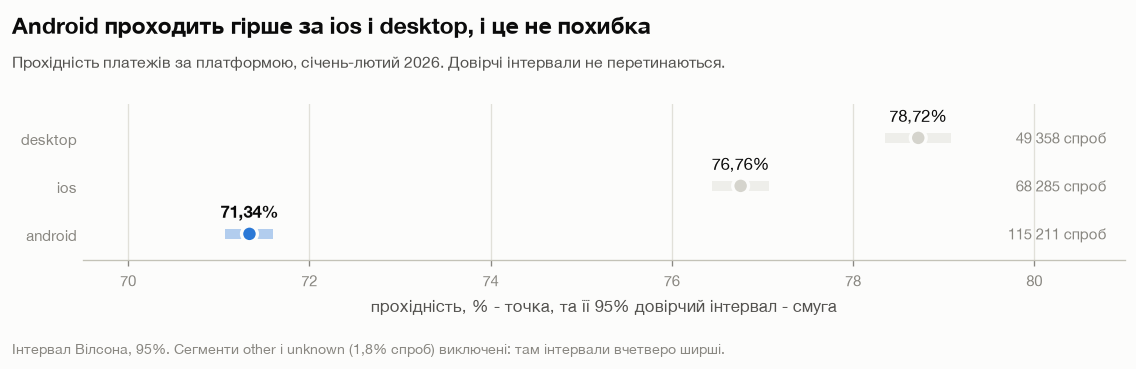

In [66]:
d = platform_ci.loc[['android', 'ios', 'desktop']].sort_values('approval_pct')
y = range(len(d))
colors = [ACCENT if s == 'android' else DIM for s in d.index]

fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.hlines(y, d.ci_low, d.ci_high, color=colors, linewidth=6, alpha=0.35)
ax.scatter(d.approval_pct, y, s=90, color=colors, zorder=3,
           edgecolors=SURFACE, linewidths=2)

for i, (name, row) in enumerate(d.iterrows()):
    bold = 'bold' if name == 'android' else 'normal'
    ax.text(row.approval_pct, i + 0.26, f'{row.approval_pct:.2f}%'.replace('.', ','),
            ha='center', va='bottom', fontsize=10, color=INK, fontweight=bold)
    ax.text(80.8, i, f'{num(row.attempts)} спроб', ha='right', va='center',
            fontsize=9, color=MUTED)

ax.set_yticks(list(y), d.index)
ax.set_xlim(69.5, 81)
ax.set_ylim(-0.55, len(d) - 0.3)
ax.set_xlabel('прохідність, % - точка, та її 95% довірчий інтервал - смуга')
ax.grid(axis='y', visible=False)
ax.tick_params(axis='y', length=0)
despine(ax)

layout(fig,
       'Android проходить гірше за ios і desktop, і це не похибка',
       'Прохідність платежів за платформою, січень-лютий 2026. Довірчі інтервали не перетинаються.',
       'Інтервал Вілсона, 95%. Сегменти other і unknown (1,8% спроб) виключені: там інтервали вчетверо ширші.')
plt.show()

Довірчі інтервали трьох основних платформ не перетинаються, тому порядок встановлено надійно. У сегментів other і unknown інтервали помітно ширші, бо там мало спроб, і точні значення для них читати не варто.

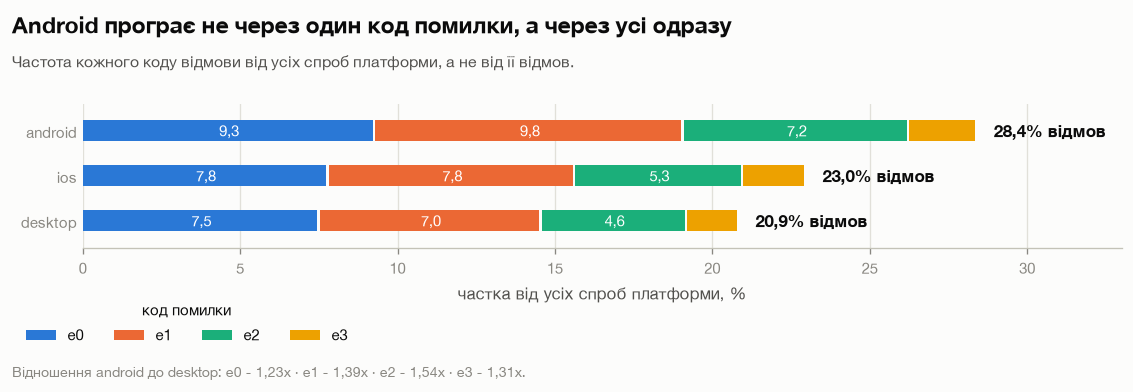

In [67]:
codes, labels = ['e0_pct', 'e1_pct', 'e2_pct', 'e3_pct'], ['e0', 'e1', 'e2', 'e3']
d = errors_by_platform.set_index('platform').loc[['desktop', 'ios', 'android'], :]
y = range(len(d))
GAP = 0.09          # ~2px розриву між сегментами

fig, ax = plt.subplots(figsize=(9.5, 3.4))
left = np.zeros(len(d))
for col, label, colour in zip(codes, labels, SERIES):
    vals = d[col].to_numpy(dtype=float)
    ax.barh(y, vals - GAP, left=left, height=0.46, color=colour, label=label)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 2.5:
            ax.text(l + v / 2, i, f'{v:.1f}'.replace('.', ','), ha='center',
                    va='center', fontsize=9, color='white')
    left = left + vals

for i, total in enumerate(left):
    ax.text(total + 0.5, i, f'{total:.1f}% відмов'.replace('.', ','), va='center',
            fontsize=10, color=INK, fontweight='bold')

ax.set_yticks(list(y), d.index)
ax.set_xlim(0, 33)
ax.set_ylim(-0.6, len(d) - 0.4)
ax.set_xlabel('частка від усіх спроб платформи, %')
ax.grid(axis='y', visible=False)
ax.tick_params(axis='y', length=0)
despine(ax)
legend_below(fig, ax, ncols=4, title='код помилки', title_fontsize=9)

layout(fig,
       'Android програє не через один код помилки, а через усі одразу',
       'Частота кожного коду відмови від усіх спроб платформи, а не від її відмов.',
       'Відношення android до desktop: e0 - 1,23x · e1 - 1,39x · e2 - 1,54x · e3 - 1,31x.',
       legend_h=0.30)
plt.show()

Це головний графік розділу про відмови. Якби провал android спричиняв один код, його стовпчик виділявся б, а решта збігалися б із desktop. Натомість підвищені всі чотири. Тому шукати треба не помилку в інтеграції, а різницю в аудиторії або в сценарії оплати.

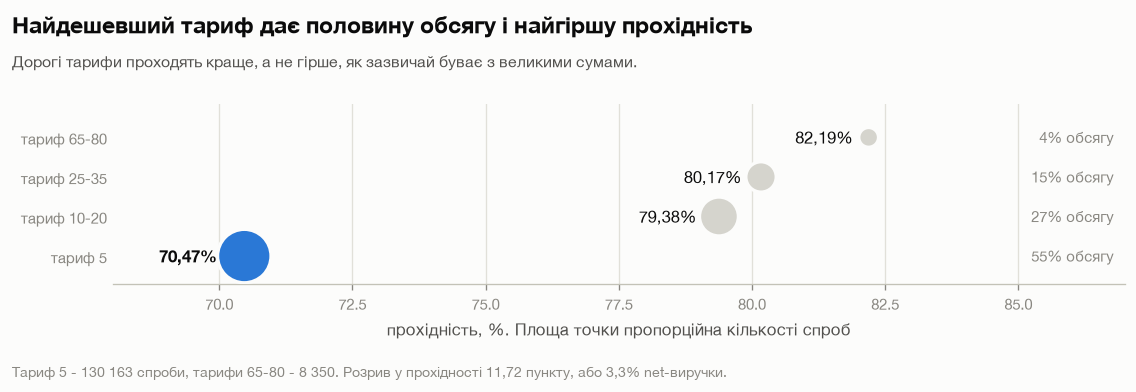

In [68]:
tier_order = ['5', '10-20', '25-35', '65-80']
d = (metrics_by('amount_tier').set_index('segment').loc[tier_order]
     .assign(share=lambda x: 100 * x.attempts / x.attempts.sum()))
y = range(len(d))
colors = [ACCENT] + [DIM] * 3

fig, ax = plt.subplots(figsize=(9.5, 3.4))
# площа точки пропорційна кількості спроб: обсяг і прохідність на одній осі
sizes = 80 + 950 * d.attempts / d.attempts.max()
ax.scatter(d.approval_pct, y, s=sizes, color=colors, zorder=3,
           edgecolors=SURFACE, linewidths=2)

for i, row in enumerate(d.itertuples()):
    pad = 0.16 + 0.011 * np.sqrt(sizes.iloc[i])      # відступ під радіус точки
    ax.text(row.approval_pct - pad, i, f'{row.approval_pct:.2f}%'.replace('.', ','),
            ha='right', va='center', fontsize=10, color=INK,
            fontweight='bold' if i == 0 else 'normal')
    ax.text(86.8, i, f'{row.share:.0f}% обсягу', ha='right', va='center',
            fontsize=9, color=MUTED)

ax.set_yticks(list(y), [f'тариф {t}' for t in tier_order])
ax.set_xlim(68, 87)
ax.set_ylim(-0.7, len(d) - 0.15)
ax.set_xlabel('прохідність, %. Площа точки пропорційна кількості спроб')
ax.grid(axis='y', visible=False)
ax.tick_params(axis='y', length=0)
despine(ax)

layout(fig,
       'Найдешевший тариф дає половину обсягу і найгіршу прохідність',
       'Дорогі тарифи проходять краще, а не гірше, як зазвичай буває з великими сумами.',
       'Тариф 5 - 130 163 спроби, тарифи 65-80 - 8 350. Розрив у прохідності 11,72 пункту, або 3,3% net-виручки.')
plt.show()

Дві шкали навмисно рознесені по двох панелях, а не накладені на одну вісь: у них різні одиниці, і поєднання в одному полі створило б видимість зв'язку, якого дані не показують.

Тариф 5 це 55% усіх спроб і водночас найгірша прохідність. Саме він тягне загальний показник до 74,70%.

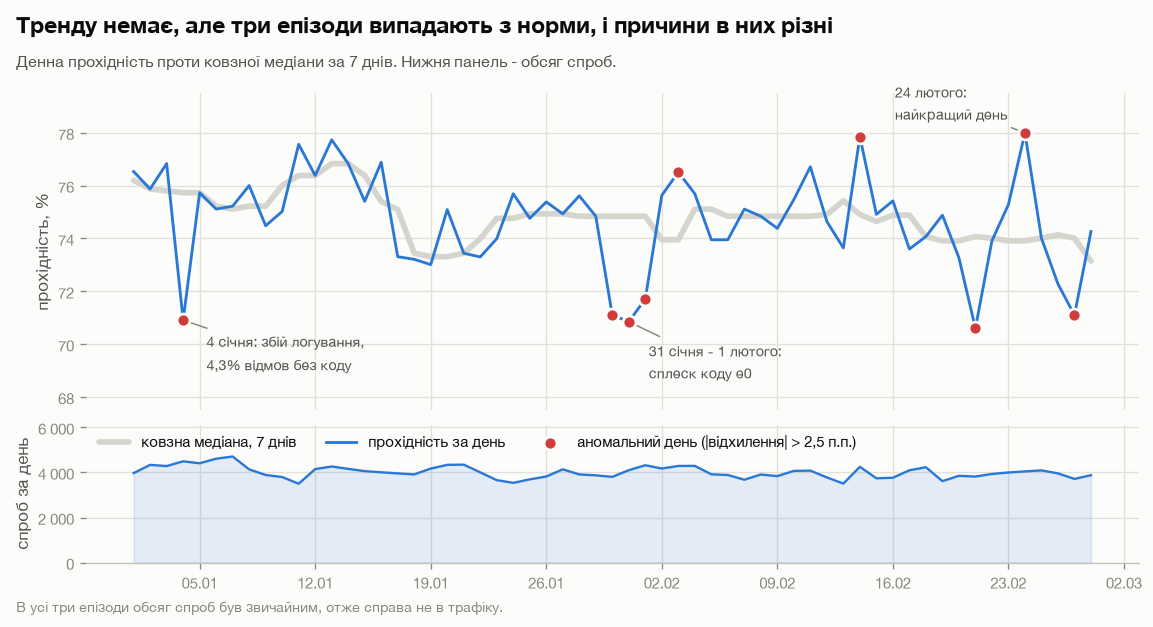

In [69]:
import matplotlib.dates as mdates

d = daily.copy()
d['tx_date'] = pd.to_datetime(d.tx_date)
d['roll'] = d.approval_pct.rolling(7, center=True, min_periods=4).median()
anom = calendar_anomalies.assign(tx_date=lambda x: pd.to_datetime(x.tx_date))

fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.4), sharex=True, layout='constrained',
                         gridspec_kw={'height_ratios': [2.3, 1]})

ax = axes[0]
ax.plot(d.tx_date, d.roll, color=DIM, linewidth=3.4, solid_capstyle='round',
        label='ковзна медіана, 7 днів')
ax.plot(d.tx_date, d.approval_pct, color=ACCENT, linewidth=1.7,
        label='прохідність за день')
ax.scatter(anom.tx_date, anom.approval_pct, s=60, color=ALERT, zorder=4,
           edgecolors=SURFACE, linewidths=1.6, label='аномальний день (|відхилення| > 2,5 п.п.)')

notes = {'2026-01-04': ('4 січня: збій логування,\n4,3% відмов без коду', 14, -30),
         '2026-01-31': ('31 січня - 1 лютого:\nсплеск коду e0', 12, -34),
         '2026-02-24': ('24 лютого:\nнайкращий день', -78, 8)}
for date, (text, dx, dy) in notes.items():
    row = anom.loc[anom.tx_date == pd.Timestamp(date)]
    if len(row):
        ax.annotate(text, xy=(row.tx_date.iloc[0], row.approval_pct.iloc[0]),
                    xytext=(dx, dy), textcoords='offset points', fontsize=8.6,
                    color=INK_2, linespacing=1.4,
                    arrowprops=dict(arrowstyle='-', color=MUTED, linewidth=0.9,
                                    shrinkA=0, shrinkB=5))

ax.set_ylabel('прохідність, %')
ax.set_ylim(67.5, 79.5)
despine(ax, keep=())
ax.tick_params(bottom=False)

ax = axes[1]
ax.fill_between(d.tx_date, d.attempts, color=ACCENT, alpha=0.12)
ax.plot(d.tx_date, d.attempts, color=ACCENT, linewidth=1.4)
ax.set_ylabel('спроб за день')
ax.set_ylim(0, d.attempts.max() * 1.3)
ax.yaxis.set_major_formatter(lambda v, p: num(v) if v else '0')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
despine(ax)

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='upper left', ncols=3, bbox_to_anchor=(0, 1.04))
layout(fig,
       'Тренду немає, але три епізоди випадають з норми, і причини в них різні',
       'Денна прохідність проти ковзної медіани за 7 днів. Нижня панель - обсяг спроб.',
       'В усі три епізоди обсяг спроб був звичайним, отже справа не в трафіку.')
plt.show()

Два місяці даних не показують жодного тренду: рівень тримається біля 74-75%.

Три підписані епізоди мають різну природу. 4 січня це збій логування, там стрибнула частка відмов без коду. 30 січня - 1 лютого це сплеск коду e0, який тривав три дні. 24 лютого це найкращий день періоду без видимої причини в даних.

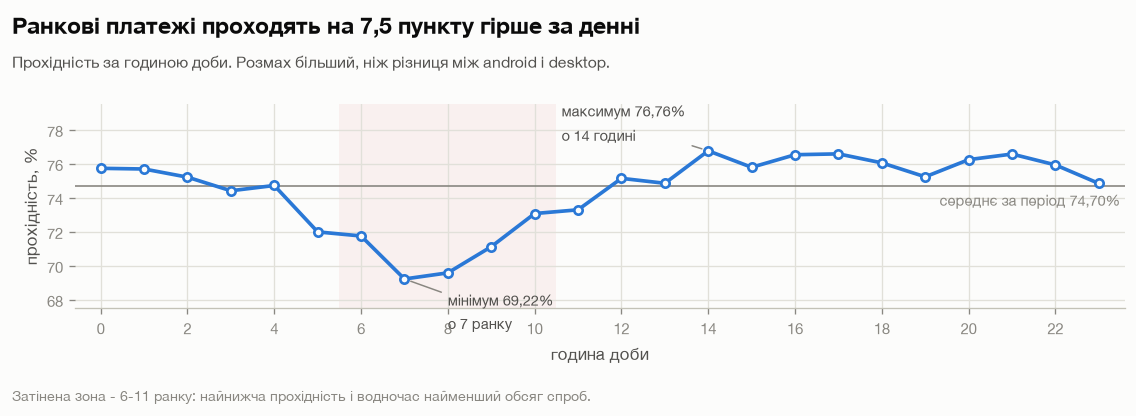

In [70]:
d = by_hour
worst, best = int(d.approval_pct.idxmin()), int(d.approval_pct.idxmax())

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.axvspan(5.5, 10.5, color=ALERT, alpha=0.06, zorder=0, linewidth=0)
ax.axhline(74.70, color=MUTED, linewidth=1, zorder=1)
ax.text(23.5, 74.35, 'середнє за період 74,70%', ha='right', va='top',
        fontsize=8.8, color=MUTED)
ax.plot(d.hour_of_day, d.approval_pct, color=ACCENT, linewidth=2.2,
        marker='o', markersize=5, markerfacecolor=SURFACE, markeredgewidth=1.6)

ax.annotate('мінімум 69,22%\nо 7 ранку', xy=(worst, d.approval_pct[worst]),
            xytext=(26, -30), textcoords='offset points', fontsize=8.8,
            color=INK_2, linespacing=1.4,
            arrowprops=dict(arrowstyle='-', color=MUTED, linewidth=0.9, shrinkB=4))
ax.annotate('максимум 76,76%\nо 14 годині', xy=(best, d.approval_pct[best]),
            xytext=(-88, 6), textcoords='offset points', fontsize=8.8,
            color=INK_2, linespacing=1.4,
            arrowprops=dict(arrowstyle='-', color=MUTED, linewidth=0.9, shrinkB=4))

ax.set_xticks(range(0, 24, 2))
ax.set_yticks(range(68, 80, 2))
ax.set_xlim(-0.6, 23.6)
ax.set_ylim(67.5, 79.5)
ax.set_xlabel('година доби')
ax.set_ylabel('прохідність, %')
despine(ax)

layout(fig,
       'Ранкові платежі проходять на 7,5 пункту гірше за денні',
       'Прохідність за годиною доби. Розмах більший, ніж різниця між android і desktop.',
       'Затінена зона - 6-11 ранку: найнижча прохідність і водночас найменший обсяг спроб.')
plt.show()

Це найбільший за розмахом ефект з усіх знайдених, і найдешевший для перевірки. Провал вузький, з дна о сьомій ранку, і припадає на години з найменшим обсягом. Найімовірніша гіпотеза це нічні або ранкові автосписання, які частіше впираються в брак коштів на картці.

У даних немає ознаки, що транзакція рекурентна, тому гіпотезу перевірити нічим. Але зсув розкладу автосписань на вечір це експеримент вартістю в один спринт.

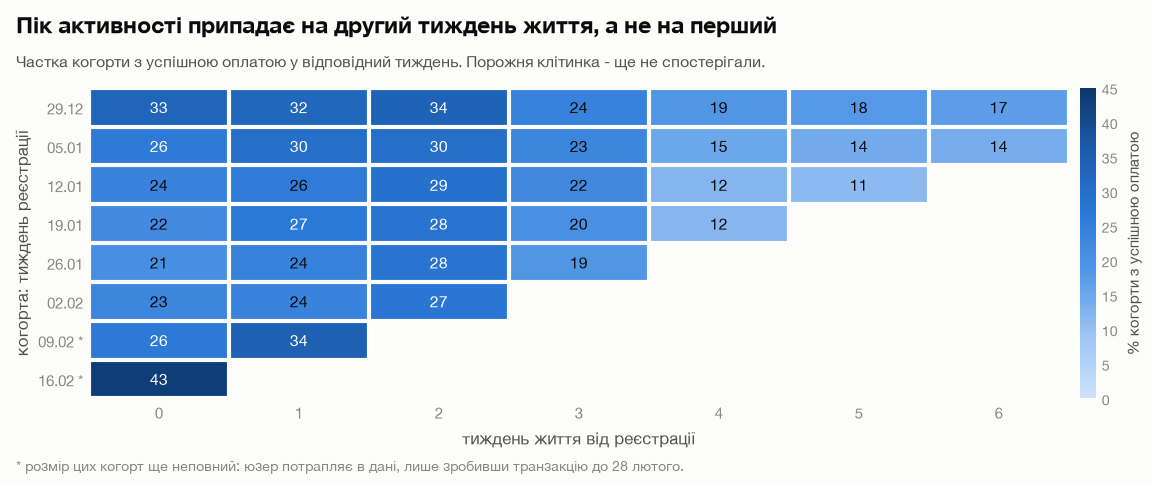

In [71]:
grid = retention_grid.copy()
grid.index = pd.to_datetime(grid.index).strftime('%d.%m')
grid = grid.dropna(how='all')                      # когорти без жодної видимої клітинки
censored = ['09.02', '16.02']                      # розмір ще неповний через селекцію
row_labels = [f'{i} *' if i in censored else i for i in grid.index]

fig, ax = plt.subplots(figsize=(9.5, 4.2), layout='constrained')
data = grid.to_numpy(dtype=float)
cmap = SEQ.copy()
cmap.set_bad(SURFACE)
im = ax.imshow(np.ma.masked_invalid(data), cmap=cmap, aspect='auto', vmin=0, vmax=45)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if not np.isnan(data[i, j]):
            ax.text(j, i, f'{data[i, j]:.0f}', ha='center', va='center', fontsize=9.5,
                    color='white' if data[i, j] > 26 else INK)

ax.set_xticks(range(grid.shape[1]), [str(c) for c in grid.columns])
ax.set_yticks(range(len(row_labels)), row_labels)
ax.set_xlabel('тиждень життя від реєстрації')
ax.set_ylabel('когорта: тиждень реєстрації')
ax.grid(visible=False)
ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
ax.grid(which='minor', color=SURFACE, linewidth=2.5)
ax.tick_params(which='both', length=0)
despine(ax, keep=())

cb = fig.colorbar(im, ax=ax, pad=0.012, fraction=0.028)
cb.set_label('% когорти з успішною оплатою', fontsize=9, color=INK_2)
cb.outline.set_visible(False)
cb.ax.tick_params(color=MUTED, labelcolor=MUTED, labelsize=8.5, length=0)

layout(fig,
       'Пік активності припадає на другий тиждень життя, а не на перший',
       'Частка когорти з успішною оплатою у відповідний тиждень. Порожня клітинка - ще не спостерігали.',
       '* розмір цих когорт ще неповний: юзер потрапляє в дані, лише зробивши транзакцію до 28 лютого.')
plt.show()

Порожні клітинки це принципово. Якби на їхньому місці стояли нулі, трикутник показував би обвал retention там, де насправді просто немає даних.

Форма рядка нетипова для підписки: активність не спадає з першого тижня, а зростає до другого. Разом із затримкою першої оплати на 11 днів це вказує на пробний період приблизно на два тижні.

Рухаючись вниз по стовпцю другого тижня видно повільне погіршення з 33,5% до 27,3%.

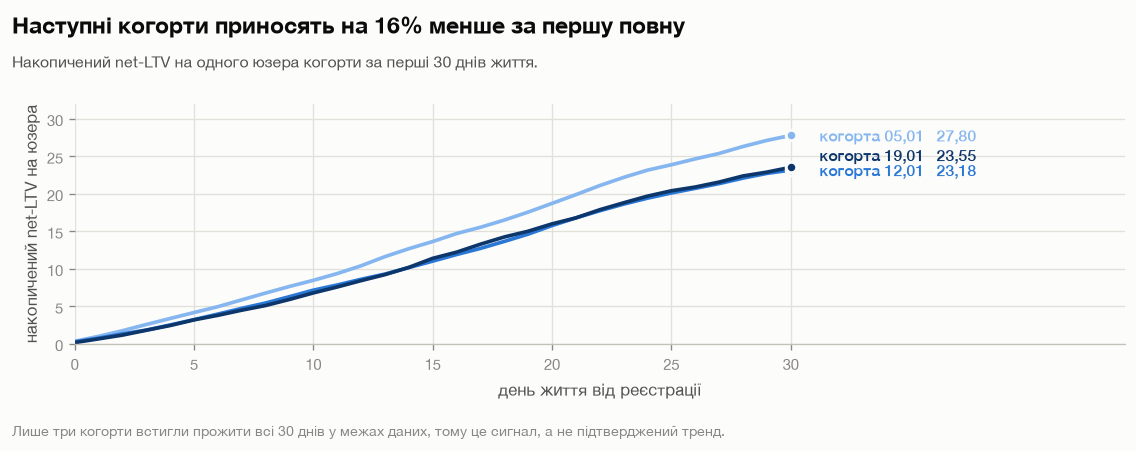

In [72]:
# беру лише когорти, які встигли прожити 30 днів у межах даних, інакше
# порівнювались би значення на різних днях життя
d = cohort_ltv[cohort_ltv.observable].assign(cohort_week=lambda x: x.cohort_week.astype(str))
reach30 = [c for c in d.cohort_week.unique() if d[(d.cohort_week == c) & (d.day_of_life == 30)].size]
reach30 = [c for c in reach30 if c != '2025-12-29'][-3:]

fig, ax = plt.subplots(figsize=(9.5, 3.9))
ends = []
for colour, cohort in zip(ORDINAL, reach30):
    s = d[(d.cohort_week == cohort) & (d.day_of_life <= 30)]
    ax.plot(s.day_of_life, s.cum_ltv, color=colour, linewidth=2.2)
    end = s.iloc[-1]
    ax.scatter([end.day_of_life], [end.cum_ltv], s=40, color=colour, zorder=3,
               edgecolors=SURFACE, linewidths=1.8)
    ends.append([end.cum_ltv, end.cum_ltv, colour,
                 pd.Timestamp(cohort).strftime('%d.%m')])

# рознести підписи, що злипаються: 12.01 і 19.01 відрізняються на 0,37
ends.sort(key=lambda e: e[0])
for prev, cur in zip(ends, ends[1:]):
    cur[1] = max(cur[1], prev[1] + 2.0)
for value, y_pos, colour, label in ends:
    ax.text(31.2, y_pos, f'когорта {label}   {value:.2f}'.replace('.', ','),
            va='center', fontsize=9.5, color=colour, fontweight='medium')

ax.set_xlim(0, 44)
ax.set_ylim(0, 32)
ax.set_xticks(range(0, 31, 5))
ax.set_xlabel('день життя від реєстрації')
ax.set_ylabel('накопичений net-LTV на юзера')
despine(ax)

layout(fig,
       'Наступні когорти приносять на 16% менше за першу повну',
       'Накопичений net-LTV на одного юзера когорти за перші 30 днів життя.',
       'Лише три когорти встигли прожити всі 30 днів у межах даних, тому це сигнал, а не підтверджений тренд.')
plt.show()

Криві майже прямі, тобто юзер платить рівномірно протягом життя, без сплеску на старті.

Перша повна когорта, 5 січня, на 30 день життя набирає 27,80, дві наступні 23,18 і 23,55. Розрив із першою складає близько 16%, але між собою дві останні когорти не впорядковані.

Повне вікно в 30 днів мають лише три когорти з дев'яти, тому називати це трендом зарано. Це сигнал, за яким варто стежити далі.

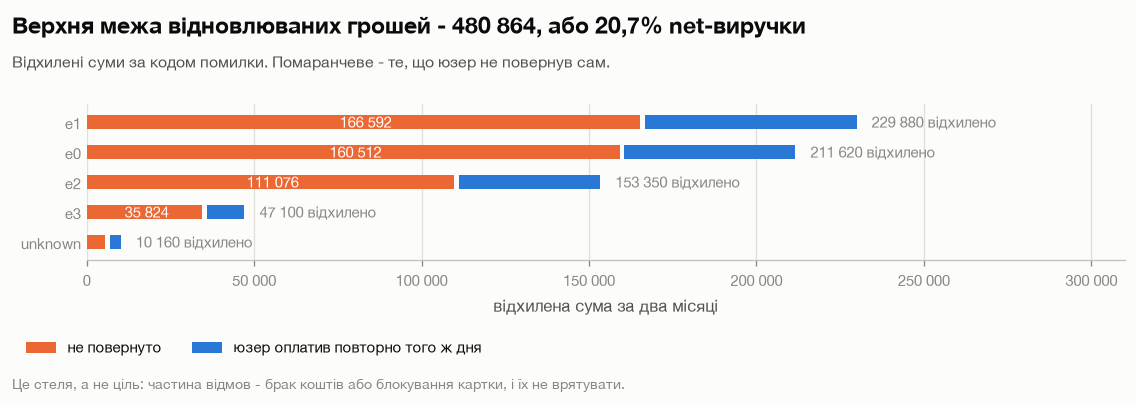

In [73]:
d = (error_money[error_money.error_label != 'РАЗОМ']
     .set_index('error_label').loc[['e1', 'e0', 'e2', 'e3', 'unknown']][::-1])
recovered = d.declined_amount - d.unrecovered_amount
y = range(len(d))
GAP = 1300          # ~2px розриву між сегментами

fig, ax = plt.subplots(figsize=(9.5, 3.5))
ax.barh(y, d.unrecovered_amount - GAP, height=0.46, color=SERIES[1],
        label='не повернуто')
ax.barh(y, recovered, left=d.unrecovered_amount, height=0.46, color=SERIES[0],
        label='юзер оплатив повторно того ж дня')

for i, (unrec, tot) in enumerate(zip(d.unrecovered_amount, d.declined_amount)):
    if unrec > 30000:
        ax.text(unrec / 2, i, num(unrec), ha='center', va='center',
                fontsize=9, color='white')
    ax.text(tot + 4500, i, f'{num(tot)} відхилено', va='center',
            fontsize=9, color=MUTED)

ax.set_yticks(list(y), d.index)
ax.set_xlim(0, 310000)
ax.set_ylim(-0.6, len(d) - 0.4)
ax.set_xlabel('відхилена сума за два місяці')
ax.xaxis.set_major_formatter(lambda v, p: num(v) if v else '0')
ax.grid(axis='y', visible=False)
ax.tick_params(axis='y', length=0)
despine(ax)
legend_below(fig, ax, ncols=2)

layout(fig,
       'Верхня межа відновлюваних грошей - 480 864, або 20,7% net-виручки',
       'Відхилені суми за кодом помилки. Помаранчеве - те, що юзер не повернув сам.',
       'Це стеля, а не ціль: частина відмов - брак коштів або блокування картки, і їх не врятувати.',
       legend_h=0.30)
plt.show()

Правий, синій сегмент це гроші, які компанія отримала без жодних зусиль, бо юзер сам повторив спробу того ж дня. Це 26% усіх відхилених сум.

Лівий, помаранчевий сегмент це те, що лишилось на столі. Найбільші шматки за кодами e1 і e0.

Число 480 864 треба читати як верхню межу. Реалістична частка, яку можна відіграти розумною ретрай-логікою і роботою зі сценарієм, помітно менша, але навіть десята частина від цієї суми варта роботи.

# Висновки та рекомендації

## Стан справ

За два місяці компанія обробила 236 918 спроб оплати від 40 210 юзерів, з них 74,70% успішних. Net-виручка 2 325 365, ARPU 57,83 на активного юзера. Chargeback-rate 0,544% від успішних транзакцій, це впевнено нижче за поріг Visa VDMP у 0,9%, тому регуляторного ризику зараз немає.

Тренду за період немає: прохідність рівна, обсяг рівний. Це означає, що всі знайдені проблеми не свіжі, а структурні, і вони будуть відтворюватись, доки їх не чіпати.

## Рекомендації, за пріоритетом

**1. Розібратись, чому android програє. Оцінка ефекту до 4,2% net-виручки.**

Android це 115 211 спроб, майже половина обсягу, і найгірша прохідність (71,34% проти 78,72% на desktop). Ефект переходить у гроші двічі: через втрачені платежі і через LTV, який на android складає 22,33 проти 32,91 на desktop.

Важливо, з чого починати. Усі чотири коди відмов на android підвищені одночасно, у 1,23-1,54 раза. Це означає, що шукати треба не баг в одному кроці, а різницю в аудиторії або в наскрізному сценарії оплати. Конкретно я б перевірив три речі: чи однаковий набір платіжних методів на android і desktop, чи не відрізняється сценарій 3DS, і чи не приходить на android інший трафік за джерелом залучення.

**2. Перенести автосписання з ранку на вечір. Оцінка ефекту невелика, вартість перевірки мінімальна.**

Розмах прохідності по годинах доби складає 7,54 пункту: 69,22% о сьомій ранку проти 76,76% о другій дня, і вечірні години тримаються майже на тому ж рівні (76,57% о дев'ятій вечора). Це більший розрив, ніж між платформами, і найдешевша гіпотеза для перевірки з усіх у цьому звіті. Якщо частина списань відбувається за розкладом, зсув вікна на вечірні години не вимагає жодних змін у продукті.

**3. Розібратись із тарифом 5. Оцінка ефекту до 3,3% net-виручки.**

Тариф 5 це 130 163 спроби, 55% обсягу, і прохідність 70,47% проти 82,19% у дорогих тарифів. Це протилежно звичайній картині, коли великі суми відхиляються частіше, тому пояснення лежить не в сумі як такій. Найімовірніше, за тарифом 5 стоїть інший продуктовий сценарій, наприклад пробне або мінімальне списання, куди потрапляють картки гіршої якості. Перевірити це в наявних даних неможливо, потрібен тип продукту.

**4. Побудувати ретрай-логіку навколо коду e0.**

Чверть усіх відмов уже зараз лікується повторною спробою того ж дня без жодних зусиль з боку компанії. Це говорить, що канал для автоматичного ретраю робочий. Починати варто з коду e0: він масовий (33,3% відмов), відновлюється гірше за інші масові коди (24,2%) і найчастіше стає останньою транзакцією юзера (37,2% усіх, хто пішов на відмові).

Верхня межа всього, що можна повернути, це 480 864, або 20,7% net-виручки. Це стеля, а не ціль: частина відмов це брак коштів і блокування карток.

**5. Залишити обидва карткові бренди.**

Різниці між Visa і Mastercard немає ні в прохідності (74,76% проти 74,64%, p-value 0,51), ні в chargeback-rate (p-value 0,81), ні в LTV(30) (тест Манна-Вітні, p-value вище 0,05). Довірчий інтервал різниці прохідності від мінус 0,23 до плюс 0,47 пункту, тобто навіть якщо різниця існує, вона мізерна. Відмова від будь-якого бренду коштувала б половини обсягу платежів без жодного виграшу.

**6. Полагодити логування кодів відмов.**

659 фейлів не мають коду помилки, і третина з них припадає на один день, 4 січня. Того ж дня прохідність провалилась на 4,82 пункту. Поки логування діряве, частину інцидентів буде видно тільки постфактум і без причини.

**7. З'ясувати, що таке канал з невизначеною платформою.**

413 юзерів, у яких платформа не проставлена в жодній транзакції, показують найкращі показники в базі: прохідність 87,39%, LTV(30) 51,42, частка платників 93,4%. Це не випадкові пропуски, а окремий канал. Якщо зрозуміти, що це, можливо, знайдеться щось, що варто масштабувати.

## Що варто відстежувати далі

LTV(30) по когортах падає з 27,80 у когорти 5 січня до 23,55 у когорти 19 січня, приблизно на 15%. Двох місяців замало, щоб назвати це трендом, але це головний кандидат на моніторинг.

## Обмеження цього аналізу

Вікно даних лише два місяці, тому повний LTV непорахувати в принципі, а всі когортні висновки зроблені на усічених горизонтах.

Юзер потрапляє в датасет тільки якщо зробив хоча б одну транзакцію. Тих, хто зареєструвався і жодного разу не спробував заплатити, тут немає взагалі, тому ARPU це показник на активного юзера, а не на зареєстрованого.

Немає банку-емітента, еквайра, типу продукту і розшифровки кодів відмов. Через це причини відмов відновлені з поведінки, а не прочитані напряму, і частина висновків лишається гіпотезами, що прямо зазначено в тексті.

Валюта не вказана, тому всі грошові оцінки читаються як частки виручки, а не як абсолютні суми.

In [74]:
con.close()